# Model Definition and Evaluation
## Table of Contents
1. [Model Selection](#model-selection)
2. [Feature Engineering](#feature-engineering)
3. [Hyperparameter Tuning](#hyperparameter-tuning)
4. [Implementation](#implementation)
5. [Evaluation Metrics](#evaluation-metrics)
6. [Comparative Analysis](#comparative-analysis)


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, mean_squared_error, classification_report
# Import models you're considering


## Model Selection
Our oceanographic profiles have two dimensions (depth x size bin), where Biovolume values in neighboring depths and size bins are correlated. This suggests that the 2D pattern of Biovolume is of importance.
By visualizing these 2D patterns as heatmaps, we aim to classify Profiles using convolutional neural networks (CNN). 
- We start by testing a simple CNN and low-resolution heatmaps (with only 45 x 45 pixels)
- We aim to progress towards createing higher-resolution heatmaps with interpolation between data points which we aim to use for transfer learning.

## Feature Engineering

Beyond the baseline preprocessing, our feature engineering focused on preparing the UVP particle-biovolume profiles for convolution-based classification. First, all biovolume values were normalized on a per-profile basis to reduce the influence of varying absolute particle concentrations and highlight relative vertical distribution patterns. Each profile was then reshaped into a structured 40×17 depth–size matrix, effectively forming a 2D heatmap representation. This transformation converts the raw measurements into spatially coherent feature maps suitable for convolutional neural networks. We deliberately refrained from introducing aggregated or hand-crafted features, as CNNs are expected to extract relevant spatial and multiscale patterns directly from the heatmaps.

- adding labels
- adding squared transformation

### Defining Functions

In [2]:
# TODO  :   Function Declaration Cell

import matplotlib.pyplot as plt
import os
import numpy as np
from scipy.ndimage import gaussian_filter
from matplotlib.colors import PowerNorm, LogNorm

heatmap_data = []

## --------------------------------------------------------- ##

def pad_heatmap(
    arr: np.ndarray,
    pad_top: int = 4,
    pad_bottom: int = 4,
    pad_left: int = 1,
    pad_right: int = 1,
    value: float = 0.0,
) -> np.ndarray:
    """
    Pad ein 2D-Array (Heatmap) mit Konstanten (default: 0).

    arr:       2D-Array (H, W)
    pad_top:   zusätzliche Zeilen oben
    pad_bottom:zusätzliche Zeilen unten
    pad_left:  zusätzliche Spalten links
    pad_right: zusätzliche Spalten rechts
    value:     Füllwert (Standard: 0.0)
    """
    return np.pad(
        arr,
        pad_width=((pad_top, pad_bottom), (pad_left, pad_right)),
        mode="constant",
        constant_values=value,
    )

## --------------------------------------------------------- ##

def crop_figure(fig, trim_px=0):
    """
    Converts a Matplotlib Figure into an RGB NumPy array and crops pixels
    at all edges. Compatible with Matplotlib 3.8+.
    """
    fig.canvas.draw()
    # Try new API first (Matplotlib 3.8+)
    try:
        buf = fig.canvas.buffer_rgba()
        img = np.asarray(buf)
        # buffer_rgba() liefert ARGB → zu RGB konvertieren
        img = img[..., :3]  
    except AttributeError:
        # Fallback: ältere Matplotlib-Versionen
        w, h = fig.canvas.get_width_height()
        buf = fig.canvas.tostring_rgb()
        img = np.frombuffer(buf, dtype=np.uint8).reshape((h, w, 3))

    if trim_px != 0:
        # Pixel abschneiden
        return img[trim_px:-trim_px, trim_px:-trim_px, :]
    else:
        return img

## --------------------------------------------------------- ##

# save_all_profiles(df, size_cols[:-3], pixels=45, trim_px=0, max_profiles=15, padding=[2,2,1,3], mp="inferno", intrpl="bilinear", gamma=1, sig=0.1)
def create_profile_heatmap(df, profile_id, size_cols, out_dir, pixels=144, trim_px=0, padding=[0,0,0,0], mp=None, intrpl=None, gam=1, sig=0.1):
    """
    Save a square heatmap for a single profile as a PNG file.
    Only the heatmap is saved — no axes, labels, or surrounding whitespace.
    Now includes pixel-exact border cropping.
    """

    # 1. Profil auswählen
    prof = df[df["Profile_id"] == profile_id].copy()
    if prof.empty:
        return

    # 2. Nach Tiefe sortieren
    prof = prof.sort_values("depth_bin")

    # 3. Heatmap-Matrix generieren (z.B. 40×14 → gepaddet)
    heatmap_data = pad_heatmap(prof[size_cols].to_numpy(), pad_top=padding[0], pad_bottom=padding[1], pad_left=padding[2], pad_right=padding[3])

    # 4. Eine quadratische Figure erzeugen
    fig = plt.figure(figsize=(1, 1), dpi=pixels)
    ax = fig.add_axes([0, 0, 1, 1])   # axes füllt alles

    # 5. Heatmap plotten
    heatmap_smooth = gaussian_filter(heatmap_data, sigma=sig)

    if intrpl == None:
        intrpl = "nearest"
    else:
        intrpl=intrpl

    ax.imshow(
        heatmap_smooth,
        cmap=mp,                          # 'gray' 'inferno' 'turbo' 'magma'
        origin="upper",
        aspect="auto",
        interpolation=intrpl,               # 'nearest' 'bilinear' 'bicubic' 'lanczos' 'spline16' 'spline36'
        # vmin=np.percentile(heatmap_data, 2),
        # vmax=np.percentile(heatmap_data, 99),
        # norm=LogNorm(),
        norm=PowerNorm(gamma=gam),
    )
    
    # alles ausblenden
    ax.axis("off")

    # 6. In Array rendern → Pixel exakt abschneiden
    cropped = crop_figure(fig, trim_px=trim_px)

    plt.close(fig)  # Original-Figure schließen

    # 7. Ordner anlegen
    os.makedirs(out_dir, exist_ok=True)

    # 8. Output-Dateinamen
    safe_id = str(profile_id)
    for ch in ['/', '\\', ':', ';', ' ']:
        safe_id = safe_id.replace(ch, '_')

    filepath = os.path.join(out_dir, f"{safe_id}.png")

    # 9. Als PNG speichern
    import imageio
    imageio.imwrite(filepath, cropped)


## --------------------------------------------------------- ##

# save_all_profiles(df, size_cols[:-3], pixels=45, trim_px=0, max_profiles=15, padding=[2,2,1,3], mp="inferno", intrpl="bilinear", gamma=1, sig=0.1)
def save_all_profiles(df, size_cols, out_dir="../Data/heatmaps", pixels=144, trim_px=0, max_profiles=None, padding=None, mp=None, intrpl=None, gamma=1, sig=0.1):
    """
    Ruft create_profile_heatmap() für viele Profile auf.
    - max_profiles = None  → alle Profile
    - max_profiles = 10    → nur die ersten 10 Profile
    """
    os.makedirs(out_dir, exist_ok=True)

    profile_ids = df["Profile_id"].unique()

    # Wenn max_profiles gesetzt ist, nur die ersten N
    if max_profiles is not None:
        profile_ids = profile_ids[:max_profiles]

    for pid in profile_ids:
        create_profile_heatmap(df, pid, size_cols, out_dir, pixels=pixels, trim_px=trim_px, padding=padding, mp=mp, intrpl=intrpl, gam=gamma, sig=sig)

## --------------------------------------------------------- ##

def normalize_by_profile_global_max(df, group_col, columns):
    """
    Normalisiert die angegebenen Spalten so, dass:
    - pro Gruppe (group_col, z.B. 'Profile-ID') genau EIN globales Maximum
      über alle angegebenen Spalten und alle Zeilen gesucht wird
    - alle Werte der Gruppe durch dieses globale Maximum geteilt werden
    - 0 bleibt 0
    """

    # 1. Relevante Spalten extrahieren
    sub = df[columns]

    # 2. Pro Gruppe (Profile) das Spaltenmaximum bestimmen
    #    → ergibt für jede Zeile einer Gruppe dieselben Spaltenmaxima
    group_col_max = df.groupby(group_col)[columns].transform("max")

    # 3. Aus diesen Spaltenmaxima das globale Maximum pro Gruppe ableiten
    #    → für jede Zeile einer Gruppe derselbe Skalar
    profile_max = group_col_max.max(axis=1)

    # 4. Division durch 0 vermeiden (Profil komplett 0)
    denom = profile_max.replace(0, 1)

    # 5. Alles durch diesen Skalar teilen
    normalized = sub.div(denom, axis=0)

    # 6. Zurück ins Original-DataFrame schreiben
    df_norm = df.copy()
    df_norm[columns] = normalized

    return df_norm

### Loading Dataset for Plotting Heatmpas

This plot shows all 40 depth bins over 14 instead of 17 size classes of bio volume,
hence the baselinemodel evaluated those classes 15-17 as insignificant.
Each square represents a real datapoint.

*****

WE WILL HAVE TO DISTORED THIS PLOT INTO A SQUARE IMAGE WITHOUT LOSING DATA OR ROUNDING ERRORS.
A 3:1 RATIO BETWEEN 'DEPTH BINS' AND 'SIZE CLASSES SHOULD DELIVER SUFFICIENT SQUARITY,
WHILE 'ZERO'-PADDING ROWS AND COLUMNS TO REACH A PIXELPERFECT RESULT.


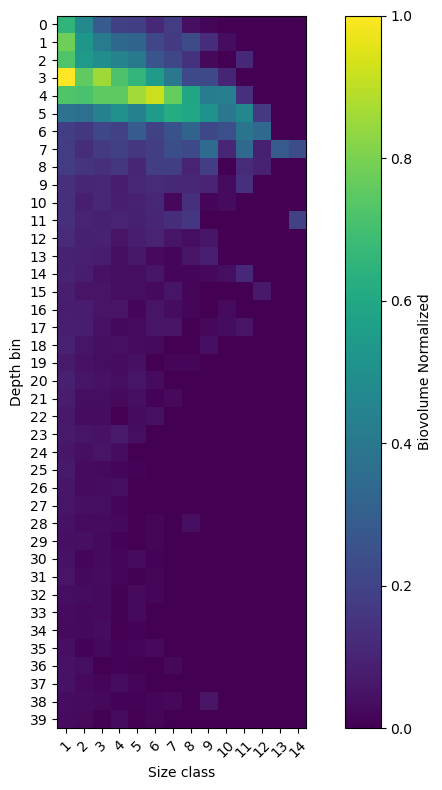

This is a sample of a padded Bioprofile, the way it gets put into the plot function.
⬇︎ This particular padding is static and only an example. ⬇︎


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
1,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
2,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
3,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
4,0.0,0.653745,0.470178,0.287066,0.188709,0.185985,0.113002,0.179574,0.041313,0.017411,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
5,0.0,0.780362,0.530190,0.415375,0.334251,0.323694,0.213776,0.168894,0.228241,0.126525,0.034254,0.000000,0.000000,0.000000,0.000000,0.0
6,0.0,0.725989,0.536002,0.490964,0.447350,0.403615,0.263119,0.212265,0.147485,0.022054,0.000000,0.112848,0.000000,0.000000,0.000000,0.0
7,0.0,1.000000,0.755412,0.859124,0.719881,0.659883,0.553178,0.400242,0.219777,0.220892,0.103590,0.000000,0.000000,0.000000,0.000000,0.0
8,0.0,0.724283,0.711253,0.750594,0.750754,0.860820,0.921165,0.763016,0.591890,0.425577,0.428972,0.139844,0.000000,0.000000,0.000000,0.0
9,0.0,0.379674,0.364668,0.437849,0.500825,0.439851,0.548332,0.618897,0.596689,0.508930,0.395237,0.467939,0.164274,0.000000,0.000000,0.0


In [3]:
# TODO  :   Load the dataset
# Replace 'your_dataset.csv' with the path to your actual dataset
import pandas as pd

df = pd.read_pickle('../Data/Biovolume_per_size_class_and_depth_updated.pkl')

# Perform any feature engineering steps
# Example: df['new_feature'] = df['feature1'] + df['feature2']

import matplotlib.pyplot as plt
import numpy as np

# 1. Biovolume-Spalten auswählen
size_cols = [col for col in df.columns if col.startswith("Biovolume ")]
# Remove three of the largest size bins
size_cols = size_cols[:-3]

# Normalisierung – kann man machen wird grafisch aber schon automatisch vom plot erledigt
df = normalize_by_profile_global_max(df, "Profile_id", size_cols)
# display(df.head(40))

# 2. Ein Profil auswählen
pid = "0000a_WMO5906623_recovery_profiles"   # hier deine echte Profile_id einsetzen
df_prof = df[df["Profile_id"] == pid].copy()

# 3. Nach Tiefe sortieren (wichtig für "saubere" y-Achse)
df_prof = df_prof.sort_values("depth_bin")

# 4. 2D-Array für die Heatmap bauen: (n_depth_bins x n_size_classes)
heatmap_data = df_prof[size_cols].to_numpy()  # Shape ~ (40, 17)

# 5. Plotten
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(
    heatmap_data,
    aspect="equal",      # oder "equal" wenn du willst
    origin="upper"      # Tiefen von unten nach oben
)

# Achsen-Beschriftungen
ax.set_xlabel("Size class")
ax.set_ylabel("Depth bin")

# Optional: Ticks mit Spaltennamen
ax.set_xticks(np.arange(len(size_cols)))
ax.set_xticklabels(range(1, len(size_cols)+1), rotation=45)

ax.set_yticks(np.arange(len(df_prof["depth_bin"].unique())))
ax.set_yticklabels(sorted(df_prof["depth_bin"].unique()))

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Biovolume Normalized")

plt.tight_layout()

print(f"="*100)
print("This plot shows all 40 depth bins over 14 instead of 17 size classes of bio volume,\nhence the baselinemodel evaluated those classes 15-17 as insignificant.\nEach square represents a real datapoint.")
print("\n"+f"*"*5+"\n")
print("WE WILL HAVE TO DISTORED THIS PLOT INTO A SQUARE IMAGE WITHOUT LOSING DATA OR ROUNDING ERRORS.")
print("A 3:1 RATIO BETWEEN 'DEPTH BINS' AND 'SIZE CLASSES SHOULD DELIVER SUFFICIENT SQUARITY,\nWHILE 'ZERO'-PADDING ROWS AND COLUMNS TO REACH A PIXELPERFECT RESULT.")
print(f"="*100)

plt.show()

print(f"="*100)
print("This is a sample of a padded Bioprofile, the way it gets put into the plot function.\n⬇︎ This particular padding is static and only an example. ⬇︎")
print(f"="*100)
pd.DataFrame(pad_heatmap(heatmap_data))

### Creating Heatmap Plots and Saving them to Files 

In [ ]:
# TODO  :   Converting our input features into heatmaps and export them as an image dataset.

# Normalizing the size columns.
size_cols = [col for col in df.columns if col.startswith("Biovolume ")]
df = normalize_by_profile_global_max(df, "Profile_id", size_cols)

"""
This first part is for redundancy only.
It has been done in a differnet cell before but doesn't always travel.
So we keep it here for 'ease of use'.
"""

## --------------------------------------------------------- ##

# Creating and storing the feature-heatmaps in a directory of your choice (default: '/Data/heatmaps').
# save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples", pixels=240, trim_px=2, max_profiles=15, sig=0.1)

save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_00", pixels=45, trim_px=0, max_profiles=3, padding=[2,3,1,0])
save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_01", pixels=48, trim_px=1, max_profiles=3, padding=[4,4,1,1])
save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_02", pixels=48, trim_px=1, max_profiles=3, padding=[4,4,1,1], intrpl="bilinear")
save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_03", pixels=48, trim_px=1, max_profiles=3, padding=[4,4,1,1], intrpl="bicubic")

save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_10", pixels=45, trim_px=0, max_profiles=3, padding=[2,3,1,0], mp="gray")
save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_11", pixels=48, trim_px=1, max_profiles=3, padding=[4,4,1,1], mp="gray")
save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_12", pixels=48, trim_px=1, max_profiles=3, padding=[4,4,1,1], mp="gray", intrpl="bilinear")
save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_13", pixels=48, trim_px=1, max_profiles=3, padding=[4,4,1,1], mp="gray", intrpl="bicubic")

save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_20", pixels=45, trim_px=0, max_profiles=3, padding=[2,3,1,0], mp="inferno")
save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_21", pixels=48, trim_px=1, max_profiles=3, padding=[4,4,1,1], mp="inferno")
save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_22", pixels=48, trim_px=1, max_profiles=3, padding=[4,4,1,1], mp="inferno", intrpl="bilinear")
save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_23", pixels=48, trim_px=1, max_profiles=3, padding=[4,4,1,1], mp="inferno", intrpl="bicubic")

save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_30", pixels=45, trim_px=0, max_profiles=3, padding=[2,3,1,0], mp="turbo")
save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_31", pixels=48, trim_px=1, max_profiles=3, padding=[4,4,1,1], mp="turbo")
save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_32", pixels=48, trim_px=1, max_profiles=3, padding=[4,4,1,1], mp="turbo", intrpl="bilinear")
save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_33", pixels=48, trim_px=1, max_profiles=3, padding=[4,4,1,1], mp="turbo", intrpl="bicubic")

"""
Here you are able to create the heatmap image output.
    pixels = [48, 144, 240] – are good choices and multiples of 16 (Columns/ Features)
            → 0·1·1·1·1·1·1·1·1·1·1·1·1·1·1·0 (one column padding on either side)

    - df: your dataframe
    - size_cols: how many biovolume size columns should be accounted for
    - out_dir: pick your output dir, this is more for putting out sample data so you don't overwrite your main dataset.
    - pixels: image square size
    - trim_px: cropping image by removing pixels along each side of the square → here you choose how many (by default there is always one line of pixels removed)
    - max_profiles: also more for test purposes
    - sig: sigma parameter of the gaussian filter of the cubic interpolation function

The full ⬇︎ image set creator uses a 240px square with 1px trim resulting in a 238px square heatmap.
The output you find in your '/Data/heatmaps/' directory. 
"""

# TODO : Uncomment for final outpput!! ⬇︎

#save_all_profiles(df, size_cols[:-3])                             # save all profile heatmaps
#save_all_profiles(df, size_cols[:-3], pixels=48, trim_px=1, max_profiles=None, padding=[4,4,1,1], mp="turbo", intrpl="bicubic")
#save_all_profiles(df, size_cols[:-3], out_dir="heatmaps_samples_03", pixels=48, trim_px=1, max_profiles=15, padding=[4,4,1,1], mp="inferno", intrpl="bilinear", gamma=1, sig=0.1)

ModuleNotFoundError: No module named 'imageio'

## First CNN: small heatmaps
-  workflow with small heatmaps & geographical & clster-stratified split

In [ ]:
# install if necessary:
#pip install imbalanced-learn pillow

In [1]:
## install if necessary:
#pip install imbalanced-learn pillow

import numpy as np
import pandas as pd
import pickle
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GaussianNoise
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from PIL import Image
import warnings
warnings.filterwarnings('ignore')


# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Path attributes

DATA_DIR = Path("../Data")
HEATMAP_DIR = DATA_DIR / "heatmaps"

### Functions for: data & heatmap loading, train/test splitting, balancing training data & scaling heatmap pixels

In [2]:

######################## initialize a class with attributes = data directories and files ###############################
# add every new function to this class

class HeatmapCNNClassifier:
    def __init__(self, data_dir=DATA_DIR, heatmap_dir=HEATMAP_DIR):
            self.data_dir = Path(data_dir)
            self.heatmap_dir = Path(heatmap_dir)
            self.train_test_file = self.data_dir / "Profile_id_to_train_test_cross_val_v2.pkl"
            self.clusters_file = self.data_dir / "Profile_id_to_clusters_4_and_6.pkl"
            self.scaler = StandardScaler()
            self.label_encoder = LabelEncoder()
        
######################## Load data assignments ###############################

def load_data_assignments(self):
    """Load data assignments from pickle files"""
    print("Loading data assignments...")
    
    # Load train/test and cross-validation assignments (DataFrame)
    with open(self.train_test_file, 'rb') as f:
        train_test_df = pickle.load(f)
    
    # Load cluster assignments (DataFrame)
    with open(self.clusters_file, 'rb') as f:
        clusters_df = pickle.load(f)
        clusters_df['cluster'] = clusters_df['cluster_4']       ######## change the number of clusters here as needed
    
    print(f"Train/test DataFrame shape: {train_test_df.shape}")
    print(f"Clusters DataFrame shape: {clusters_df.shape}")
    print(f"Train/test columns: {train_test_df.columns.tolist()}")
    print(f"Clusters columns:  {clusters_df.columns.tolist()}")
    
    # Convert DataFrames to dictionaries for easier lookup
    # Assuming Profile_id is the key column
    self.train_test_cv = {}
    for _, row in train_test_df.iterrows():
        profile_id = row['Profile_id']
        # Create dictionary with remaining columns
        self.train_test_cv[profile_id] = {col: row[col] for col in train_test_df.columns if col != 'Profile_id'}
    
    self.clusters = {}
    for _, row in clusters_df.iterrows():
        profile_id = row['Profile_id']
        # Assuming there's a cluster column - let's find it
        cluster_cols = [col for col in clusters_df.columns if col != 'Profile_id']
        if len(cluster_cols) == 1:
            self.clusters[profile_id] = row[cluster_cols[0]]
        else:
            # If multiple columns, store as dictionary
            self.clusters[profile_id] = {col: row[col] for col in cluster_cols}
    
    print(f"Loaded assignments for {len(self.train_test_cv)} profiles")
    print(f"Loaded cluster assignments for {len(self.clusters)} profiles")
    
    # Show sample data structure
    sample_profile = list(self.train_test_cv.keys())[0]
    print(f"Sample train/test data for profile {sample_profile}:  {self.train_test_cv[sample_profile]}")
    print(f"Sample cluster data for profile {sample_profile}:  {self.clusters[sample_profile]}")

# add the function to the class
HeatmapCNNClassifier.load_data_assignments = load_data_assignments

######################## Load heatmaps ###############################

def load_heatmaps(self):
    """Load heatmap images and create feature matrices"""
    print("Loading heatmap images...")
    
    # Get list of available heatmap files
    heatmap_files = list(self.heatmap_dir.glob("*.png"))
    print(f"Found {len(heatmap_files)} PNG files in {self.heatmap_dir}")
    
    if len(heatmap_files) == 0:
        raise FileNotFoundError(f"No PNG files found in {self.heatmap_dir}")
    
    # Extract profile IDs from filenames (remove .png extension)
    available_profile_ids = [f.stem for f in heatmap_files]
    
    # Debug: Show sample filenames and extracted profile IDs
    sample_files = heatmap_files[:5]
    sample_ids = [f.stem for f in sample_files]
    print(f"Sample filenames: {[f.name for f in sample_files]}")
    print(f"Sample extracted profile IDs: {sample_ids}")
    
    # Convert profile IDs to consistent format (strings)
    train_test_ids = set(str(k) for k in self.train_test_cv.keys())
    cluster_ids = set(str(k) for k in self.clusters.keys())
    filename_ids = set(str(id_) for id_ in available_profile_ids)
    
    print(f"Available profile IDs from filenames: {len(filename_ids)}")
    print(f"Profile IDs with train/test data: {len(train_test_ids)}")
    print(f"Profile IDs with cluster data:  {len(cluster_ids)}")
    
    # Find common profile IDs across all data sources
    common_with_train_test = filename_ids & train_test_ids
    common_with_clusters = filename_ids & cluster_ids
    common_all = filename_ids & train_test_ids & cluster_ids
    
    print(f"Files matching train/test IDs: {len(common_with_train_test)}")
    print(f"Files matching cluster IDs: {len(common_with_clusters)}")
    print(f"Files matching all data sources: {len(common_all)}")
    
    if len(common_all) == 0:
        print("\nDEBUGGING: No matching profile IDs found!")
        print("Sample IDs from each source:")
        print(f"Filenames: {list(filename_ids)[:5]}")
        print(f"Train/test:  {list(train_test_ids)[:5]}")
        print(f"Clusters: {list(cluster_ids)[:5]}")
        raise ValueError("No matching profile IDs found between files and metadata")
    
    common_ids = list(common_all)
    print(f"Found {len(common_ids)} profiles with complete data")
    
    # Load images and extract data
    X_data = []
    y_data = []
    profile_ids = []
    data_types = []
    cv_folds = []
    
    # Load a sample image to get dimensions
    sample_profile_id = common_ids[0]
    sample_img_path = self.heatmap_dir / f"{sample_profile_id}.png"
    sample_img = Image.open(sample_img_path)
    sample_array = np.array(sample_img)
    img_shape = sample_array.shape
    print(f"Image dimensions: {img_shape}")
    
    for profile_id_str in common_ids:
        # Convert string back to original type for dictionary lookup
        # Try both string and original type
        lookup_id = profile_id_str
        for original_id in self.train_test_cv.keys():
            if str(original_id) == profile_id_str:
                lookup_id = original_id
                break
        
        # Load image
        img_path = self.heatmap_dir / f"{profile_id_str}.png"
        img = Image.open(img_path)
        img_array = np.array(img)
        
        # Normalize pixel values to [0, 1]
        if img_array.dtype == np.uint8:
            img_array = img_array.astype(np.float32) / 255.0
        
        X_data.append(img_array)
        
        # Extract cluster assignment
        cluster_data = self.clusters[lookup_id]
        if isinstance(cluster_data, dict):
            # If cluster data is a dictionary, assume first value is the cluster
            y_data.append(list(cluster_data.values())[0])
        else:
            y_data.append(cluster_data)
        
        profile_ids.append(profile_id_str)
        data_types.append(self.train_test_cv[lookup_id]['data_type'])
        cv_folds.append(self.train_test_cv[lookup_id]['CV_fold'])
    
    self.X_data = np.array(X_data)
    self.y_data = np.array(y_data)
    self.profile_ids = np.array(profile_ids)
    self.data_types = np.array(data_types)
    self.cv_folds = np.array(cv_folds)
    
    print(f"Loaded {len(self.X_data)} heatmaps with shape {self.X_data.shape}")
    print(f"Unique clusters found: {np.unique(self.y_data)}")
    print(f"Data types found: {np.unique(self.data_types)}")
    print(f"CV folds found: {np.unique(self.cv_folds)}")

# add the function to the class
HeatmapCNNClassifier.load_heatmaps = load_heatmaps


######################## Train/test split ###############################

def split_train_test(self):
    """Split data into train and test sets based on pre-defined assignments"""
    print("Splitting data into train and test sets...")
    
    train_mask = self.data_types == 'train'
    test_mask = self.data_types == 'test'
    
    self.X_train = self.X_data[train_mask]
    self.y_train = self.y_data[train_mask]
    self.train_profile_ids = self.profile_ids[train_mask]
    self.train_cv_folds = self.cv_folds[train_mask]
    
    self.X_test = self.X_data[test_mask]
    self.y_test = self.y_data[test_mask]
    self.test_profile_ids = self.profile_ids[test_mask]
    
    print(f"Training set:  {len(self.X_train)} samples")
    print(f"Test set: {len(self.X_test)} samples")
    
    # Encode labels
    self.y_train_encoded = self.label_encoder.fit_transform(self.y_train)
    self.y_test_encoded = self.label_encoder.transform(self.y_test)
    self.n_classes = len(self.label_encoder.classes_)
    
    print(f"Number of classes: {self.n_classes}")
    print(f"Classes: {self.label_encoder.classes_}")

# add the function to the class
HeatmapCNNClassifier.split_train_test = split_train_test


######################## Balance classes per fold - SMOTE Tomek link ###############################

def balance_classes_per_fold_SMOTETomek(self):
    """Apply balancing within each CV fold separately"""
    print("Balancing classes per fold using SMOTETomek (SMOTE + Tomek links)...")
    
    unique_folds = np.unique(self.train_cv_folds)
    print(f"Processing {len(unique_folds)} folds:  {unique_folds}")
    
    # Store balanced data for each fold
    self.fold_balanced_data = {}
    
    for fold in unique_folds:
        print(f"\nBalancing fold:  {fold}")
        
        # Get training data for this fold (all other folds)
        val_mask = self.train_cv_folds == fold
        train_mask = ~val_mask
        
        X_train_fold = self.X_train[train_mask]
        y_train_fold = self.y_train_encoded[train_mask]
        
        print(f"Original fold {fold} training size: {len(X_train_fold)}")
        
        # Check if balancing is needed for this fold
        fold_counts = Counter(y_train_fold)
        min_count = min(fold_counts.values())
        max_count = max(fold_counts.values())
        
        if max_count / min_count > 1.5:  # Apply balancing if imbalanced
            # Reshape data for resampling (flatten images)
            X_train_fold_flat = X_train_fold.reshape(len(X_train_fold), -1)
            
            # Apply SMOTETomek
            smote_tomek = SMOTETomek(
                smote=SMOTE(random_state=42, k_neighbors=min(3, min_count-1)),
                tomek=TomekLinks(),
                random_state=42
            )
            
            X_train_balanced, y_train_balanced = smote_tomek.fit_resample(X_train_fold_flat, y_train_fold)
            
            # Reshape back to image format
            X_train_balanced = X_train_balanced.reshape((-1,) + X_train_fold.shape[1:])
            
            print(f"Balanced fold {fold} training size: {len(X_train_balanced)}")
            
            # Show distribution after balancing
            balanced_counts = Counter(y_train_balanced)
            for cluster_idx, count in sorted(balanced_counts.items()):
                cluster_name = self.label_encoder.classes_[cluster_idx]
                print(f"  Cluster {cluster_name}: {count} samples")
                
        else:
            print(f"Fold {fold} is already balanced, no resampling needed")
            X_train_balanced = X_train_fold
            y_train_balanced = y_train_fold
        
        # Store balanced data for this fold
        self.fold_balanced_data[fold] = {
            'X_train': X_train_balanced,
            'y_train': y_train_balanced,
            'X_val': self.X_train[val_mask],
            'y_val': self.y_train_encoded[val_mask]
        }

# add the function to the class
HeatmapCNNClassifier.balance_classes_per_fold_SMOTETomek = balance_classes_per_fold_SMOTETomek


######################## Balance classes per fold - Oversampling and undersampling ###############################

def balance_classes_per_fold_simple(self):
    """Apply simple over/undersampling to mean cluster size within each CV fold"""
    print("Balancing classes per fold using simple over/undersampling to mean...")
    
    unique_folds = np.unique(self.train_cv_folds)
    print(f"Processing {len(unique_folds)} folds: {unique_folds}")
    
    # Store balanced data for each fold
    self.fold_balanced_data = {}
    
    for fold in unique_folds: 
        print(f"\nBalancing fold: {fold}")
        
        # Get training data for this fold (all other folds)
        val_mask = self.train_cv_folds == fold
        train_mask = ~val_mask
        
        X_train_fold = self.X_train[train_mask]
        y_train_fold = self.y_train_encoded[train_mask]
        
        print(f"Original fold {fold} training size: {len(X_train_fold)}")
        
        # Calculate cluster distribution
        fold_counts = Counter(y_train_fold)
        total_samples = len(y_train_fold)
        n_clusters = len(fold_counts)
        target_per_cluster = total_samples // n_clusters  # Mean number per cluster
        
        print(f"Target samples per cluster: {target_per_cluster}")
        print("Original distribution:", dict(fold_counts))
        
        # Check if balancing is needed
        min_count = min(fold_counts.values())
        max_count = max(fold_counts.values())
        
        if max_count / min_count > 1.5:  # Apply balancing if imbalanced
            X_balanced_list = []
            y_balanced_list = []
            
            for cluster_idx in sorted(fold_counts.keys()):
                # Get all samples for this cluster
                cluster_mask = y_train_fold == cluster_idx
                X_cluster = X_train_fold[cluster_mask]
                y_cluster = y_train_fold[cluster_mask]
                
                current_count = len(X_cluster)
                cluster_name = self.label_encoder.classes_[cluster_idx]
                
                if current_count < target_per_cluster:
                    # OVERSAMPLE:  randomly duplicate samples to reach target
                    n_to_add = target_per_cluster - current_count
                    print(f"  Oversampling Cluster {cluster_name}:  {current_count} -> {target_per_cluster} (+{n_to_add})")
                    
                    # Randomly sample with replacement
                    oversample_indices = np.random.choice(len(X_cluster), 
                                                        size=n_to_add, 
                                                        replace=True)
                    X_oversampled = X_cluster[oversample_indices]
                    y_oversampled = y_cluster[oversample_indices]
                    
                    # Combine original + oversampled
                    X_cluster_balanced = np.vstack([X_cluster, X_oversampled])
                    y_cluster_balanced = np.concatenate([y_cluster, y_oversampled])
                    
                elif current_count > target_per_cluster:
                    # UNDERSAMPLE: randomly select subset to reach target
                    print(f"  Undersampling Cluster {cluster_name}: {current_count} -> {target_per_cluster} (-{current_count - target_per_cluster})")
                    
                    # Randomly sample without replacement
                    undersample_indices = np.random.choice(len(X_cluster), 
                                                        size=target_per_cluster, 
                                                        replace=False)
                    X_cluster_balanced = X_cluster[undersample_indices]
                    y_cluster_balanced = y_cluster[undersample_indices]
                    
                else:
                    # Already at target size
                    print(f"  Cluster {cluster_name}:  {current_count} (no change needed)")
                    X_cluster_balanced = X_cluster
                    y_cluster_balanced = y_cluster
                
                X_balanced_list.append(X_cluster_balanced)
                y_balanced_list.append(y_cluster_balanced)
            
            # Combine all balanced clusters
            X_train_balanced = np.vstack(X_balanced_list)
            y_train_balanced = np.concatenate(y_balanced_list)
            
            # Shuffle the balanced data
            shuffle_indices = np.random.permutation(len(X_train_balanced))
            X_train_balanced = X_train_balanced[shuffle_indices]
            y_train_balanced = y_train_balanced[shuffle_indices]
            
            print(f"Balanced fold {fold} training size: {len(X_train_balanced)}")
            
            # Show final distribution
            final_counts = Counter(y_train_balanced)
            for cluster_idx, count in sorted(final_counts.items()):
                cluster_name = self.label_encoder.classes_[cluster_idx]
                print(f"  Final Cluster {cluster_name}: {count} samples")
                
        else:
            print(f"Fold {fold} is already balanced, no resampling needed")
            X_train_balanced = X_train_fold
            y_train_balanced = y_train_fold
        
        # Store balanced data for this fold
        self.fold_balanced_data[fold] = {
            'X_train': X_train_balanced,
            'y_train': y_train_balanced,
            'X_val': self.X_train[val_mask],
            'y_val': self.y_train_encoded[val_mask]
        }
        
    print("\nSimple balancing complete!")

# add the function to the class
HeatmapCNNClassifier.balance_classes_per_fold_simple = balance_classes_per_fold_simple


######################## Scale heatmap pixel data ###############################

def scale_data(self):
    """Scale the heatmap pixel data to get mean = 0 and std = 1
    scaler is fitted on original training data only
    and then applied to test data and balanced fold data
    no data leakage occurs this way"""

    print("Scaling heatmap pixel data...")
    
    # Scale original training data for test set evaluation
    original_shape = self.X_train.shape
    X_train_flat = self.X_train.reshape(len(self.X_train), -1)
    X_test_flat = self.X_test.reshape(len(self.X_test), -1)
    
    print(type(self.scaler))  # What scaler is being used?
    
    # Fit scaler on original training data
    X_train_scaled = self.scaler.fit_transform(X_train_flat)
    X_test_scaled = self.scaler.transform(X_test_flat)
    
    # Reshape back to image format
    self.X_train_scaled = X_train_scaled.reshape(original_shape)
    self.X_test_scaled = X_test_scaled.reshape(self.X_test.shape)
    
    print(f"Scaled training data shape: {self.X_train_scaled.shape}")
    print(f"Scaled test data shape: {self.X_test_scaled.shape}")
    
    # Scale balanced data for each fold
    if hasattr(self, 'fold_balanced_data'):
        print("Scaling balanced fold data...")
        for fold in self.fold_balanced_data.keys():
            fold_data = self.fold_balanced_data[fold]
            
            # Scale training data for this fold
            X_train_fold_flat = fold_data['X_train'].reshape(len(fold_data['X_train']), -1)
            X_val_fold_flat = fold_data['X_val'].reshape(len(fold_data['X_val']), -1)
            
            # Use same scaler fitted on original training data
            X_train_fold_scaled = self.scaler.transform(X_train_fold_flat)
            X_val_fold_scaled = self.scaler.transform(X_val_fold_flat)
            
            # Reshape back to image format
            self.fold_balanced_data[fold]['X_train_scaled'] = X_train_fold_scaled.reshape((-1,) + fold_data['X_train'].shape[1:])
            self.fold_balanced_data[fold]['X_val_scaled'] = X_val_fold_scaled.reshape((-1,) + fold_data['X_val'].shape[1:])

# add the function to the class
HeatmapCNNClassifier.scale_data = scale_data
    

### Function for data augmentation with Gaussian Noise in 1 x 3 pixel-blocks (like the data points)

Found 5619 PNG heatmap files
Loaded solace_026_0.png:  shape (46, 46, 3)
  With block_size=3, this represents 15 datapoints along x-axis
Loaded ctd078_0_new.png:  shape (46, 46, 3)
  With block_size=3, this represents 15 datapoints along x-axis
Loaded 0131a_WMO6903095.png:  shape (46, 46, 3)
  With block_size=3, this represents 15 datapoints along x-axis
Loaded e1s21_4.png:  shape (46, 46, 3)
  With block_size=3, this represents 15 datapoints along x-axis


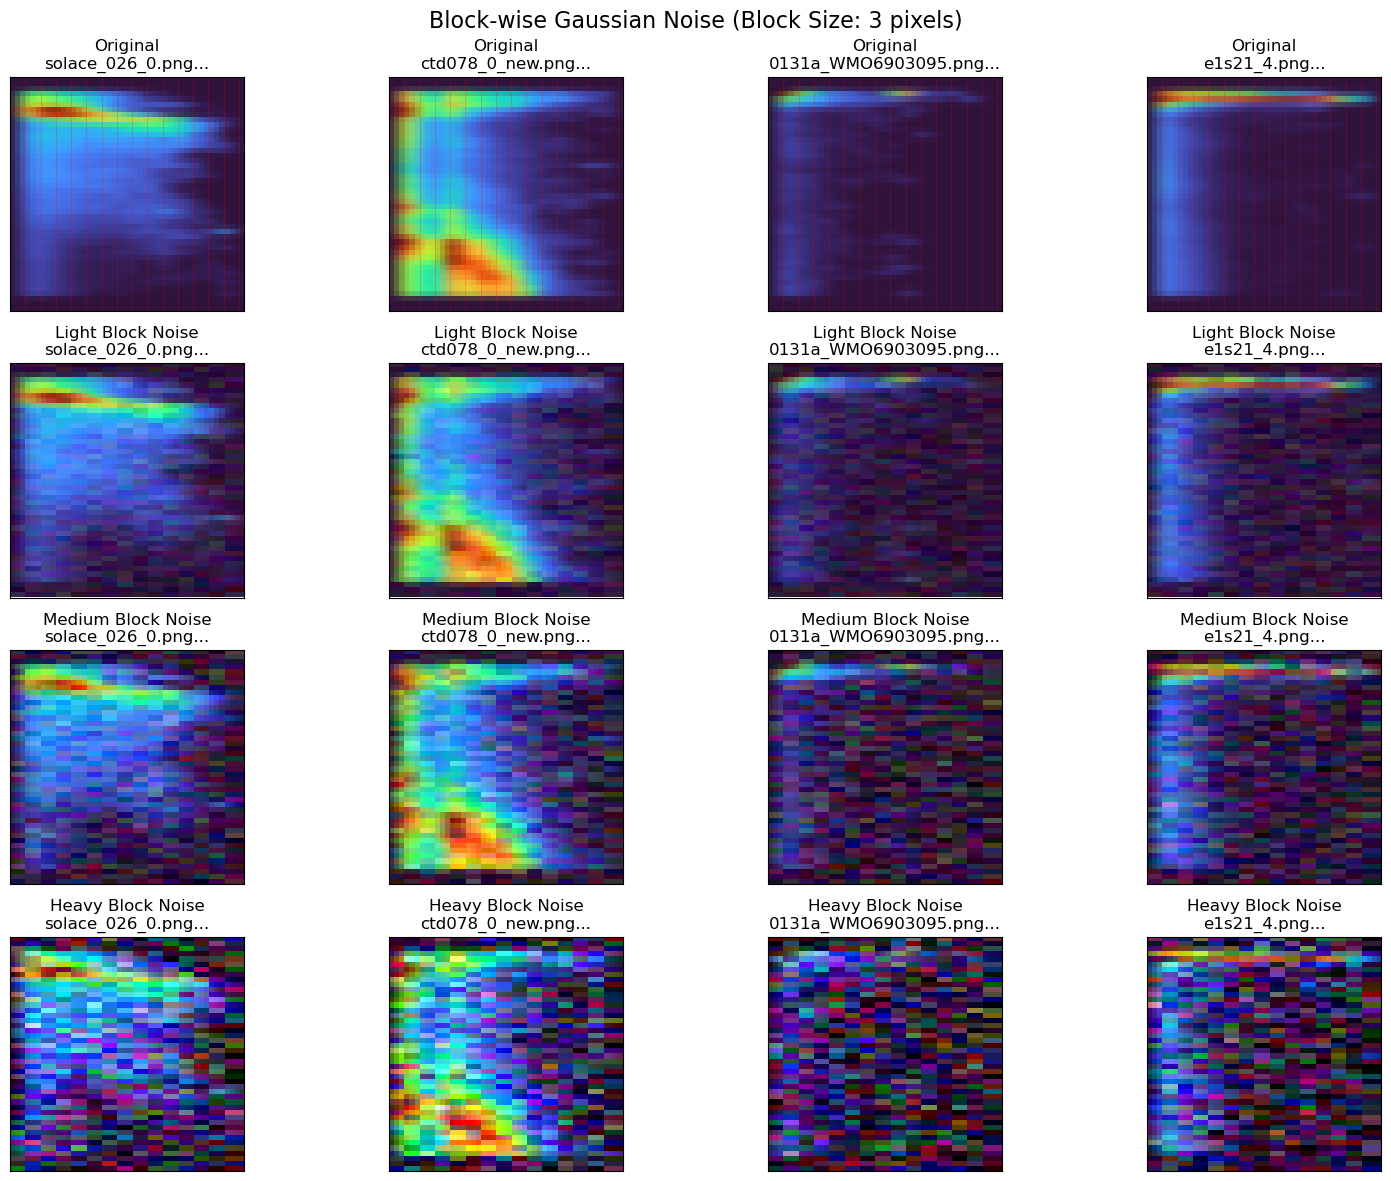


BLOCK-WISE NOISE ANALYSIS
Block size: 3 pixels per datapoint
Number of datapoints along x-axis: 15

Light Block Noise (σ = 0.05):
  Mean absolute difference: 0.0391
  Max absolute difference: 0.1608
  Within-block correlation: 1.000

Medium Block Noise (σ = 0.1):
  Mean absolute difference: 0.0772
  Max absolute difference: 0.3692
  Within-block correlation: 0.999

Heavy Block Noise (σ = 0.2):
  Mean absolute difference: 0.1446
  Max absolute difference: 0.7066
  Within-block correlation: 0.999


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import random
import os
from PIL import Image
import tensorflow as tf

def add_block_gaussian_noise(image, noise_level, block_size=3):
    """
    Add Gaussian noise in blocks of pixels along x-axis
    
    Parameters: 
    image (np.array): Input image 
    noise_level (float): Standard deviation of noise
    block_size (int): Number of pixels per block (default 3)
    """
    if noise_level == 0.0:
        return image
    
    height, width = image.shape[: 2]
    n_channels = image.shape[2] if len(image.shape) == 3 else 1
    
    # Calculate number of complete blocks along x-axis
    n_blocks = width // block_size
    effective_width = n_blocks * block_size
    
    # Create noise at the block level (one noise value per block)
    block_noise_shape = (height, n_blocks) + ((n_channels,) if n_channels > 1 else ())
    block_noise = np.random.normal(0, noise_level, block_noise_shape)
    
    # Expand each noise value to fill the entire block (repeat 3 times along x-axis)
    if n_channels > 1:
        # Multi-channel image
        pixel_noise = np.repeat(block_noise, block_size, axis=1)
        # Handle any remaining pixels if width is not divisible by block_size
        if effective_width < width:
            remaining_pixels = width - effective_width
            last_block_noise = block_noise[: , -1: , : ] 
            last_block_expanded = np.repeat(last_block_noise, remaining_pixels, axis=1)
            pixel_noise = np.concatenate([pixel_noise, last_block_expanded], axis=1)
    else:
        # Grayscale image
        pixel_noise = np.repeat(block_noise, block_size, axis=1)
        if effective_width < width:
            remaining_pixels = width - effective_width
            last_block_noise = block_noise[:, -1:]
            last_block_expanded = np.repeat(last_block_noise, remaining_pixels, axis=1)
            pixel_noise = np.concatenate([pixel_noise, last_block_expanded], axis=1)
    
    # Add noise to image and clip to valid range
    noisy_image = image + pixel_noise
    return np.clip(noisy_image, 0, 1)

def test_block_gaussian_noise(heatmap_dir="../Data/heatmaps", block_size=3):
    """
    Test block-wise Gaussian noise on PNG heatmap files
    """
    # Set random seed for reproducibility
    random.seed(42)
    np.random.seed(42)
    
    # Get random heatmap files
    heatmap_files = [f for f in os.listdir(heatmap_dir) if f.endswith('.png')]
    
    if len(heatmap_files) == 0:
        print(f"No .png files found in {heatmap_dir}")
        return
    
    print(f"Found {len(heatmap_files)} PNG heatmap files")
    selected_files = random.sample(heatmap_files, min(4, len(heatmap_files)))
    
    # Load and prepare heatmaps
    heatmaps = []
    for filename in selected_files:
        img_path = os.path.join(heatmap_dir, filename)
        img = Image.open(img_path)
        heatmap = np.array(img).astype(np.float32) / 255.0
        
        # Handle RGBA by removing alpha channel
        if len(heatmap.shape) == 3 and heatmap.shape[2] == 4:
            heatmap = heatmap[: , :, :3]
        
        print(f"Loaded {filename}:  shape {heatmap.shape}")
        print(f"  With block_size={block_size}, this represents {heatmap.shape[1]//block_size} datapoints along x-axis")
        heatmaps.append(heatmap)
    
    # Define noise levels
    noise_configs = [
        (0.0, "Original"),
        (0.05, "Light Block Noise"),  
        (0.1, "Medium Block Noise"),
        (0.2, "Heavy Block Noise")
    ]
    
    # Create plot
    fig, axes = plt.subplots(4, len(selected_files), figsize=(4*len(selected_files), 12))
    
    # Handle single file case
    if len(selected_files) == 1:
        axes = axes.reshape(-1, 1)
    
    for row, (noise_level, label) in enumerate(noise_configs):
        for col in range(len(selected_files)):
            # Apply block-wise noise
            display_data = add_block_gaussian_noise(heatmaps[col], noise_level, block_size)
            
            # Display the heatmap
            if len(display_data.shape) == 3 and display_data.shape[2] == 3:
                # RGB image
                axes[row, col].imshow(display_data)
            elif len(display_data.shape) == 3:
                # Multi-channel - average for display
                axes[row, col].imshow(np.mean(display_data, axis=-1), cmap='viridis')
            else:
                # Grayscale
                axes[row, col].imshow(display_data, cmap='viridis')
            
            axes[row, col].set_title(f"{label}\n{selected_files[col][:20]}...")
            axes[row, col].set_xticks([])
            axes[row, col].set_yticks([])
            
            # Add grid lines to show block structure (optional)
            if row == 0:  # Only on original images
                width = display_data.shape[1]
                for x in range(0, width, block_size):
                    axes[row, col].axvline(x - 0.5, color='red', alpha=0.3, linewidth=0.5)
    
    plt.suptitle(f'Block-wise Gaussian Noise (Block Size: {block_size} pixels)', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # Print noise statistics
    print("\n" + "="*60)
    print("BLOCK-WISE NOISE ANALYSIS")
    print("="*60)
    print(f"Block size: {block_size} pixels per datapoint")
    
    original = heatmaps[0]
    n_datapoints = original.shape[1] // block_size
    print(f"Number of datapoints along x-axis: {n_datapoints}")
    
    for noise_level, label in noise_configs[1:]:
        noisy = add_block_gaussian_noise(original, noise_level, block_size)
        
        mean_diff = np.mean(np.abs(noisy - original))
        max_diff = np.max(np.abs(noisy - original))
        
        # Calculate noise correlation within blocks
        block_correlation = analyze_block_structure(original, noisy, block_size)
        
        print(f"\n{label} (σ = {noise_level}):")
        print(f"  Mean absolute difference: {mean_diff:.4f}")
        print(f"  Max absolute difference: {max_diff:.4f}")
        print(f"  Within-block correlation: {block_correlation:.3f}")

def analyze_block_structure(original, noisy, block_size):
    """Analyze correlation within blocks to verify block structure"""
    height, width = original.shape[:2]
    n_blocks = width // block_size
    
    correlations = []
    noise_diff = noisy - original
    
    for block_idx in range(n_blocks):
        start_x = block_idx * block_size
        end_x = start_x + block_size
        
        if end_x <= width:
            block_noise = noise_diff[:, start_x:end_x]
            
            # Calculate correlation between adjacent pixels in the block
            if block_size > 1:
                pixel1 = block_noise[:, 0].flatten()
                pixel2 = block_noise[:, 1].flatten()
                if len(pixel1) > 0 and len(pixel2) > 0:
                    correlation = np.corrcoef(pixel1, pixel2)[0, 1]
                    if not np.isnan(correlation):
                        correlations.append(correlation)
    
    return np.mean(correlations) if correlations else 0.0

# Test the block-wise noise
test_block_gaussian_noise(heatmap_dir=HEATMAP_DIR, block_size=3)

- noise of 0.05 looks good, the higher levels are too much
- note that noise is added in 3-pixel blocks, same as the datapoint representation

In [4]:
import tensorflow as tf
from tensorflow.keras.layers import Layer

class BlockGaussianNoise(Layer):
    """Custom layer for block-wise Gaussian noise augmentation"""
    
    def __init__(self, noise_level, block_size=3, seed=None, **kwargs):
        super(BlockGaussianNoise, self).__init__(**kwargs)
        self.noise_level = noise_level
        self.block_size = block_size
        self.seed = seed
        self.supports_masking = True
    
    def build(self, input_shape):
        super(BlockGaussianNoise, self).build(input_shape)
    
    def call(self, inputs, training=None):
        if training is None:
            training = tf.keras.backend.learning_phase()
        
        def apply_noise():
            # Get input shape
            input_shape = tf.shape(inputs)
            batch_size = input_shape[0]
            height = input_shape[1]
            width = input_shape[2]
            channels = input_shape[3]
            
            # Calculate number of blocks
            n_blocks = width // self.block_size
            effective_width = n_blocks * self.block_size
            
            # Generate noise at block level
            block_noise = tf.random.normal(
                shape=[batch_size, height, n_blocks, channels],
                stddev=self.noise_level,
                seed=self.seed
            )
            
            # Repeat noise for each pixel in the block
            pixel_noise = tf.repeat(block_noise, self.block_size, axis=2)
            
            # Handle remaining pixels if width not divisible by block_size
            if effective_width < width:
                remaining = width - effective_width
                last_block = block_noise[: , :, -1:, :]
                last_expanded = tf.repeat(last_block, remaining, axis=2)
                pixel_noise = tf.concat([pixel_noise, last_expanded], axis=2)
            else:
                # Ensure pixel_noise has the correct width
                pixel_noise = pixel_noise[:, :, :width, :]
            
            # Add noise to inputs
            return inputs + pixel_noise
        
        def no_noise():
            return inputs
        
        return tf.cond(tf.cast(training, tf.bool), apply_noise, no_noise)
    
    def compute_output_shape(self, input_shape):
        return input_shape
    
    def compute_output_spec(self, input_spec):
        return input_spec
    
    def get_config(self):
        config = {
            'noise_level': self.noise_level,
            'block_size': self.block_size,
            'seed': self.seed,
        }
        base_config = super(BlockGaussianNoise, self).get_config()
        return dict(list(base_config.items()) + list(config.items()))

# Add this to your class
HeatmapCNNClassifier.BlockGaussianNoise = BlockGaussianNoise


### Functions for: CNN model creation, compiling, cross-validation with pre-defined folds

In [5]:
######################## Create CNN model - tune model architecture here ###############################
#######################

# Adjust hyperparameters
learning_rate = 0.001
dropout_rate_conv = 0.25
dropout_rate_dense = 0.5
batch_size = 32
epochs = 100
patience = 10 # patience of early stopping callback
verbose_val = 1 # no output during training
k = 4 # number of folds for cross-validation
metrics_to_monitor = ['accuracy', ]

# augmentation parameters
noise_level = 0.075 # Gaussian noise level - data augmentation
block_size = 3 # Block size for block-wise noise

######################## Create CNN model architecture ###############################

def create_cnn_model(self, input_shape):
    """Create CNN model architecture"""
    print(f"Creating CNN model for input shape: {input_shape}")
    
    model = Sequential([

        # Input layer with block-wise Gaussian noise augmentation
        BlockGaussianNoise(noise_level, block_size, seed=42, input_shape=input_shape),

        # First convolutional block
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Dropout(dropout_rate_conv),
        
        # Second convolutional block
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Dropout(dropout_rate_conv),
        
        # Third convolutional block
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Dropout(dropout_rate_conv),
        
        # Fully connected layers
        Flatten(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(dropout_rate_dense),

        Dense(256, activation='relu'),
        Dropout(dropout_rate_dense),

        Dense(self.n_classes, activation='softmax')         # Output layer for multi-class classification
    ])
    
    return model

# add the function to the class
HeatmapCNNClassifier.create_cnn_model = create_cnn_model


######################## Compile model ###############################

def compile_model(self, model):
    """Compile the CNN model"""
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=metrics_to_monitor
    )
    return model

# add the function to the class
HeatmapCNNClassifier.compile_model = compile_model


######################## Fit model once to each fold - cross-validate ###############################
def cross_validate(self):
    """Perform cross-validation using pre-defined folds with balanced data"""
    print("Starting cross-validation with balanced data...")
        
    unique_folds = list(self.fold_balanced_data.keys())
    print(f"Cross-validation folds: {unique_folds}")
    
    cv_results = {
        'balanced_accuracy': [],
        'macro_f1':  [],
        'fold_predictions':  [],
        'fold_true_labels': [],
        # Add training metrics tracking
        'train_loss': [],
        'train_accuracy': [],
        'val_loss': [],
        'val_accuracy': []
    }
    
    # Store individual fold results for confusion matrices
    self.cv_fold_results = []
    
    for fold in unique_folds:                            ### for-loop over folds
        print(f"\nProcessing fold:  {fold}")
        
        # Get balanced data for this fold
        fold_data = self.fold_balanced_data[fold]
        X_train_fold = fold_data['X_train_scaled']
        y_train_fold = fold_data['y_train']
        X_val_fold = fold_data['X_val_scaled']
        y_val_fold = fold_data['y_val']
        
        print(f"Fold {fold} - Train:  {len(X_train_fold)}, Val: {len(X_val_fold)}")
        
        # Convert to categorical: one-hot encoding of clusters for keras
        y_train_fold_cat = to_categorical(y_train_fold, self.n_classes)
        y_val_fold_cat = to_categorical(y_val_fold, self.n_classes)
        
        # Create and compile model
        model = self.create_cnn_model(X_train_fold.shape[1:])
        model = self.compile_model(model)
        
        # Set up callbacks
        early_stopping = EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)
        reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7) # reduce learning rate if no improvement (on plateau)
        
        # Train model
        history = model.fit(
            X_train_fold, y_train_fold_cat,
            validation_data=(X_val_fold, y_val_fold_cat),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[early_stopping, reduce_lr],
            verbose=verbose_val
        )
        
        # Extract final training metrics from history
        final_train_loss = history.history['loss'][-1]
        final_train_accuracy = history.history['accuracy'][-1]
        final_val_loss = history.history['val_loss'][-1]
        final_val_accuracy = history.history['val_accuracy'][-1]
        
        # Store training metrics
        cv_results['train_loss'].append(final_train_loss)
        cv_results['train_accuracy'].append(final_train_accuracy)
        cv_results['val_loss'].append(final_val_loss)
        cv_results['val_accuracy'].append(final_val_accuracy)
        
        # Make predictions for additional metrics
        y_pred_proba = model.predict(X_val_fold, verbose=verbose_val)
        y_pred = np.argmax(y_pred_proba, axis=1)
        
        # Calculate additional validation metrics
        bal_acc = balanced_accuracy_score(y_val_fold, y_pred)
        macro_f1 = f1_score(y_val_fold, y_pred, average='macro')
        
        cv_results['balanced_accuracy'].append(bal_acc)
        cv_results['macro_f1'].append(macro_f1)
        cv_results['fold_predictions'].extend(y_pred)
        cv_results['fold_true_labels'].extend(y_val_fold)
        
        # Calculate training metrics on training data
        y_train_pred_proba = model.predict(X_train_fold, verbose=verbose_val)
        y_train_pred = np.argmax(y_train_pred_proba, axis=1)
        train_bal_acc = balanced_accuracy_score(y_train_fold, y_train_pred)
        train_macro_f1 = f1_score(y_train_fold, y_train_pred, average='macro')
        
        # Store individual fold results for confusion matrices
        fold_result = {
            'fold_name': fold,
            'y_true': y_val_fold,
            'y_pred': y_pred,
            'balanced_accuracy': bal_acc,
            'macro_f1':  macro_f1,
            'n_samples': len(y_val_fold),
            # Add training metrics to fold results
            'train_loss':  final_train_loss,
            'train_accuracy': final_train_accuracy,
            'train_balanced_accuracy': train_bal_acc,
            'train_macro_f1': train_macro_f1,
            'val_loss': final_val_loss,
            'val_accuracy': final_val_accuracy
        }
        self.cv_fold_results.append(fold_result)
        
        # Print comprehensive fold results
        print(f"Fold {fold} Results:")
        print(f"  Training   - Loss: {final_train_loss:.4f}, Accuracy: {final_train_accuracy:.4f}, Bal. Acc: {train_bal_acc:.4f}, F1: {train_macro_f1:.4f}")
        print(f"  Validation - Loss: {final_val_loss:.4f}, Accuracy: {final_val_accuracy:.4f}, Bal.Acc: {bal_acc:.4f}, F1: {macro_f1:.4f}")
        
    self.cv_results = cv_results
    self.print_cv_results()

# Add the updated function to the class
HeatmapCNNClassifier.cross_validate = cross_validate

######################## Print CV results (integrated in cross_validate) ###############################

def print_cv_results(self):
    """Print comprehensive cross-validation results including training metrics"""
    
    print("\n" + "="*80)
    print("CROSS-VALIDATION RESULTS SUMMARY")
    print("="*80)
    
    # Validation metrics
    bal_acc_mean = np.mean(self.cv_results['balanced_accuracy'])
    bal_acc_std = np.std(self.cv_results['balanced_accuracy'])
    f1_mean = np.mean(self.cv_results['macro_f1'])
    f1_std = np.std(self.cv_results['macro_f1'])
    val_loss_mean = np.mean(self.cv_results['val_loss'])
    val_loss_std = np.std(self.cv_results['val_loss'])
    val_acc_mean = np.mean(self.cv_results['val_accuracy'])
    val_acc_std = np.std(self.cv_results['val_accuracy'])
    
    # Training metrics
    train_loss_mean = np.mean(self.cv_results['train_loss'])
    train_loss_std = np.std(self.cv_results['train_loss'])
    train_acc_mean = np.mean(self.cv_results['train_accuracy'])
    train_acc_std = np.std(self.cv_results['train_accuracy'])
    
    # Calculate training balanced accuracy and F1 from fold results
    train_bal_accs = [fold['train_balanced_accuracy'] for fold in self.cv_fold_results]
    train_f1s = [fold['train_macro_f1'] for fold in self.cv_fold_results]
    train_bal_acc_mean = np.mean(train_bal_accs)
    train_bal_acc_std = np.std(train_bal_accs)
    train_f1_mean = np.mean(train_f1s)
    train_f1_std = np.std(train_f1s)
    
    print("TRAINING METRICS (average across folds):")
    print(f"  Loss:                 {train_loss_mean:.4f} ± {train_loss_std:.4f}")
    print(f"  Accuracy:            {train_acc_mean:.4f} ± {train_acc_std:.4f}")
    print(f"  Balanced Accuracy:   {train_bal_acc_mean:.4f} ± {train_bal_acc_std:.4f}")
    print(f"  Macro F1 Score:      {train_f1_mean:.4f} ± {train_f1_std:.4f}")
    
    print("\nVALIDATION METRICS (average across folds):")
    print(f"  Loss:                {val_loss_mean:.4f} ± {val_loss_std:.4f}")
    print(f"  Accuracy:            {val_acc_mean:.4f} ± {val_acc_std:.4f}")
    print(f"  Balanced Accuracy:   {bal_acc_mean:.4f} ± {bal_acc_std:.4f}")
    print(f"  Macro F1 Score:      {f1_mean:.4f} ± {f1_std:.4f}")
    
    # Calculate overfitting indicators
    accuracy_gap = train_acc_mean - val_acc_mean
    loss_gap = val_loss_mean - train_loss_mean  # Higher validation loss indicates overfitting
    bal_acc_gap = train_bal_acc_mean - bal_acc_mean
    
    print("\nOVERFITTING ANALYSIS:")
    print(f"  Accuracy Gap (train - val):     {accuracy_gap:.4f}")
    print(f"  Loss Gap (val - train):         {loss_gap:.4f}")
    print(f"  Bal. Accuracy Gap (train - val): {bal_acc_gap:.4f}")
    
    if accuracy_gap > 0.1:
        print("  ⚠️  Large accuracy gap suggests overfitting")
    elif accuracy_gap < 0.02:
        print("  ✅ Good generalization (low accuracy gap)")
    else:
        print("  ➡️  Moderate accuracy gap")
    
    print("\nPER-FOLD BREAKDOWN:")
    print("Fold      | Train Acc | Val Acc | Train F1 | Val F1  | Train Loss | Val Loss")
    print("-"*75)
    for i, fold_result in enumerate(self.cv_fold_results):
        fold_name = fold_result['fold_name']
        train_acc = fold_result['train_accuracy']
        val_acc = fold_result['balanced_accuracy']  # Using balanced accuracy for validation
        train_f1 = fold_result['train_macro_f1']
        val_f1 = fold_result['macro_f1']
        train_loss = fold_result['train_loss']
        val_loss = fold_result['val_loss']
        
        print(f"{fold_name: <9} | {train_acc:.4f}    | {val_acc:.4f}  | {train_f1:.4f}   | {val_f1:.4f}  | {train_loss:.4f}     | {val_loss:.4f}")

# add the function to the class
HeatmapCNNClassifier.print_cv_results = print_cv_results


######################## Confusion Matrix Function ###############################

def plot_cv_fold_confusion_matrices(self, k=k):
    """
    Plot normalized confusion matrices for each CV fold
    
    Parameters:  
    k (int): Number of folds to display (default 4)
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import confusion_matrix
    import numpy as np
    
    if not hasattr(self, 'cv_results'):
        print("Error: No cross-validation results found.  Run cross_validate() first.")
        return
    
    if not hasattr(self, 'cv_fold_results'):
        print("Error: Individual fold results not available.")
        print("Make sure you're using the updated cross_validate() method.")
        return
    
    n_folds = min(k, len(self.cv_fold_results))
    
    # Set up the subplot grid (2x2 for 4 folds)
    if n_folds <= 2:
        fig, axes = plt.subplots(1, n_folds, figsize=(7*n_folds, 6))
        if n_folds == 1:
            axes = [axes]
    else:
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        axes = axes.flatten()
    
    # Color map for consistency
    cmap = 'Blues'
    
    print("\n" + "="*60)
    print("CV FOLD CONFUSION MATRIX SUMMARY")
    print("="*60)
    
    for fold_idx in range(n_folds):
        ax = axes[fold_idx]
        
        # Get predictions and true labels for this fold
        fold_result = self.cv_fold_results[fold_idx]
        y_true_fold = fold_result['y_true']
        y_pred_fold = fold_result['y_pred']
        fold_name = fold_result['fold_name']
        
        # Calculate confusion matrix
        cm = confusion_matrix(y_true_fold, y_pred_fold)
        
        # Normalize confusion matrix (row-wise normalization)
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        
        # Handle any NaN values (in case a class has 0 samples)
        cm_normalized = np.nan_to_num(cm_normalized)
        
        # Create heatmap
        sns.heatmap(cm_normalized, 
                   annot=True, 
                   fmt='.2f', 
                   cmap=cmap,
                   ax=ax,
                   xticklabels=self.label_encoder.classes_,
                   yticklabels=self.label_encoder.classes_,
                   vmin=0, 
                   vmax=1,
                   cbar_kws={'label': 'Normalized Count'})
        
        # Calculate accuracy for this fold
        accuracy = fold_result['balanced_accuracy']
        macro_f1 = fold_result['macro_f1']
        
        ax.set_title(f'{fold_name}\nBal.  Acc: {accuracy:.3f}, F1: {macro_f1:.3f}')
        ax.set_xlabel('Predicted Cluster')
        ax.set_ylabel('True Cluster')
        
        # Print summary for this fold
        print(f"\n{fold_name}:")
        print(f"  Samples: {fold_result['n_samples']}")
        print(f"  Balanced Accuracy: {accuracy:.3f}")
        print(f"  Macro F1: {macro_f1:.3f}")
        
        # Per-class statistics
        print("  Per-class recall (diagonal values):")
        for class_idx, class_name in enumerate(self.label_encoder.classes_):
            if class_idx < len(cm_normalized):
                recall = cm_normalized[class_idx, class_idx]
                print(f"    Cluster {class_name}: {recall:.3f}")
    
    # Hide any unused subplots
    if n_folds < len(axes):
        for idx in range(n_folds, len(axes)):
            axes[idx].axis('off')
    
    plt.suptitle('Normalized Confusion Matrices by CV Fold', fontsize=16, y=0.98)
    plt.tight_layout()
    plt.show()
    
    # Overall summary
    print(f"\n" + "="*60)
    print("OVERALL CV SUMMARY")
    print("="*60)
    all_accuracies = [fold['balanced_accuracy'] for fold in self.cv_fold_results]
    all_f1s = [fold['macro_f1'] for fold in self.cv_fold_results]
    
    print(f"Mean Balanced Accuracy: {np.mean(all_accuracies):.3f} ± {np.std(all_accuracies):.3f}")
    print(f"Mean Macro F1: {np.mean(all_f1s):.3f} ± {np.std(all_f1s):.3f}")

# Add the function to the class
HeatmapCNNClassifier.plot_cv_fold_confusion_matrices = plot_cv_fold_confusion_matrices


### Main function - full pipeline

In [6]:
def run_full_pipeline(self):
    """Run the complete pipeline"""
    print("Starting Heatmap CNN Classification Pipeline")
    print("=" * 50)
    
    # Step 1: Load data
    self.load_data_assignments()
    self.load_heatmaps()
    
    # Step 2: Split train/test
    self.split_train_test()
    
    # Step 4: Balance classes per fold
    #self.balance_classes_per_fold_SMOTETomek() # alternative: use SMOTE Tomek Link
    self.balance_classes_per_fold_simple()

    # Step 5: Scale data
    self.scale_data()
    
    # Step 6: Cross-validation
    self.cross_validate()

    # Step 7: Plot CV confusion matrices
    self.plot_cv_fold_confusion_matrices()
            
    print("\nPipeline completed successfully!")

# add the function to the class
HeatmapCNNClassifier.run_full_pipeline = run_full_pipeline


### Run pipeline

Starting Heatmap CNN Classification Pipeline
Loading data assignments...
Train/test DataFrame shape: (5619, 3)
Clusters DataFrame shape: (5619, 4)
Train/test columns: ['Profile_id', 'data_type', 'CV_fold']
Clusters columns:  ['Profile_id', 'cluster', 'cluster_4', 'cluster_6']
Loaded assignments for 5619 profiles
Loaded cluster assignments for 5619 profiles
Sample train/test data for profile s033:  {'data_type': 'test', 'CV_fold': ''}
Sample cluster data for profile s033:  {'cluster': 1, 'cluster_4': 1, 'cluster_6': 2}
Loading heatmap images...
Found 5619 PNG files in ..\Data\heatmaps
Sample filenames: ['0000a_WMO5906623_recovery_profiles.png', '0002a_WMO5906623_recovery_profiles.png', '0003a_WMO5906623_recovery_profiles.png', '0003a_WMO6904139_recovery.png', '0004a_WMO6903096.png']
Sample extracted profile IDs: ['0000a_WMO5906623_recovery_profiles', '0002a_WMO5906623_recovery_profiles', '0003a_WMO5906623_recovery_profiles', '0003a_WMO6904139_recovery', '0004a_WMO6903096']
Available pro

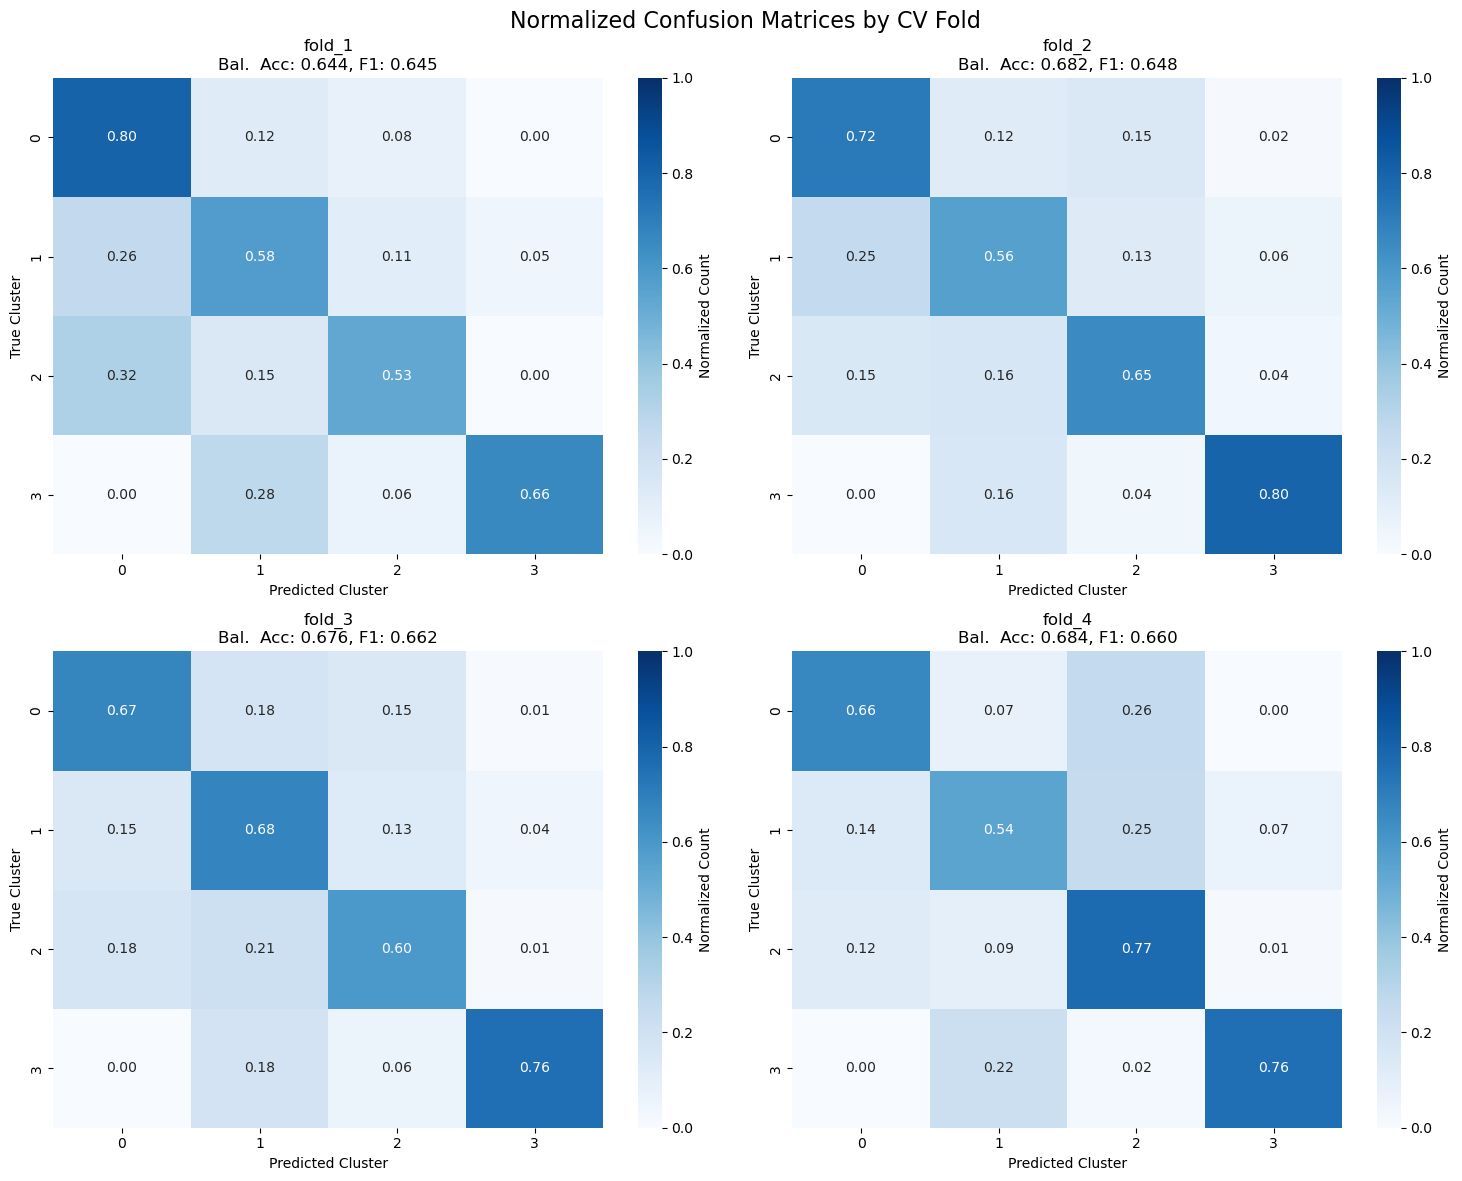


OVERALL CV SUMMARY
Mean Balanced Accuracy: 0.671 ± 0.016
Mean Macro F1: 0.654 ± 0.007

Pipeline completed successfully!


In [7]:
classifier = HeatmapCNNClassifier()
classifier.run_full_pipeline()

# Hyperparameter Tuning

[Discuss any hyperparameter tuning methods you've applied, such as Grid Search or Random Search, and the rationale behind them.]


in anaconda prompt, install ray tune: pip install "ray[tune]" optuna

In [14]:
######################## Initialize classifier and load all data ###############################

print("🚀 Initializing HeatmapCNNClassifier and loading data...")

# Initialize the classifier
classifier = HeatmapCNNClassifier()

# Load data assignments (pickle files)
print("\n📁 Step 1: Loading data assignments...")
classifier.load_data_assignments()

# Load heatmap images
print("\n🖼️ Step 2: Loading heatmap images...")
classifier.load_heatmaps()

# Split into train/test sets
print("\n📊 Step 3: Splitting train/test data...")
classifier.split_train_test()

# Balance classes per fold
print("\n⚖️ Step 4: Balancing classes per fold...")
# Choose one of the balancing methods:
# Option 1: Simple over/undersampling (faster, more predictable)
classifier.balance_classes_per_fold_simple()

# Option 2:  SMOTE-Tomek (more sophisticated but slower)
# classifier.balance_classes_per_fold_SMOTETomek()

# Scale the data
print("\n📏 Step 5: Scaling pixel data...")
classifier.scale_data()

# Verify everything is set up correctly
print("\n✅ Data setup verification:")
print(f"  Training data shape: {classifier.X_train_scaled.shape}")
print(f"  Test data shape: {classifier.X_test_scaled.shape}")
print(f"  Number of classes: {classifier.n_classes}")
print(f"  Class labels: {classifier.label_encoder.classes_}")
print(f"  CV folds available: {list(classifier.fold_balanced_data.keys())}")
print(f"  fold_balanced_data structure: ✅ Ready for optimization")

# Show sample fold data to verify structure
sample_fold = list(classifier.fold_balanced_data.keys())[0]
sample_data = classifier.fold_balanced_data[sample_fold]
print(f"\n📋 Sample fold ({sample_fold}) data:")
print(f"  X_train_scaled shape: {sample_data['X_train_scaled'].shape}")
print(f"  y_train shape: {sample_data['y_train'].shape}")
print(f"  X_val_scaled shape: {sample_data['X_val_scaled'].shape}")
print(f"  y_val shape: {sample_data['y_val'].shape}")

print("\n🎯 Classifier is now ready for hyperparameter optimization!")
print("You can now run:")
print("  best_config, results = classifier.optimize_hyperparameters_smart()")

🚀 Initializing HeatmapCNNClassifier and loading data...

📁 Step 1: Loading data assignments...
Loading data assignments...
Train/test DataFrame shape: (5619, 3)
Clusters DataFrame shape: (5619, 4)
Train/test columns: ['Profile_id', 'data_type', 'CV_fold']
Clusters columns:  ['Profile_id', 'cluster', 'cluster_4', 'cluster_6']
Loaded assignments for 5619 profiles
Loaded cluster assignments for 5619 profiles
Sample train/test data for profile s033:  {'data_type': 'test', 'CV_fold': ''}
Sample cluster data for profile s033:  {'cluster': 1, 'cluster_4': 1, 'cluster_6': 2}

🖼️ Step 2: Loading heatmap images...
Loading heatmap images...
Found 5619 PNG files in ..\Data\heatmaps
Sample filenames: ['0000a_WMO5906623_recovery_profiles.png', '0002a_WMO5906623_recovery_profiles.png', '0003a_WMO5906623_recovery_profiles.png', '0003a_WMO6904139_recovery.png', '0004a_WMO6903096.png']
Sample extracted profile IDs: ['0000a_WMO5906623_recovery_profiles', '0002a_WMO5906623_recovery_profiles', '0003a_WMO59

Starting Heatmap CNN Classification Pipeline
Loading data assignments...
Train/test DataFrame shape: (5619, 3)
Clusters DataFrame shape: (5619, 4)
Train/test columns: ['Profile_id', 'data_type', 'CV_fold']
Clusters columns:  ['Profile_id', 'cluster', 'cluster_4', 'cluster_6']
Loaded assignments for 5619 profiles
Loaded cluster assignments for 5619 profiles
Sample train/test data for profile s033:  {'data_type': 'test', 'CV_fold': ''}
Sample cluster data for profile s033:  {'cluster': 1, 'cluster_4': 1, 'cluster_6': 2}
Loading heatmap images...
Found 5619 PNG files in ..\Data\heatmaps
Sample filenames: ['0000a_WMO5906623_recovery_profiles.png', '0002a_WMO5906623_recovery_profiles.png', '0003a_WMO5906623_recovery_profiles.png', '0003a_WMO6904139_recovery.png', '0004a_WMO6903096.png']
Sample extracted profile IDs: ['0000a_WMO5906623_recovery_profiles', '0002a_WMO5906623_recovery_profiles', '0003a_WMO5906623_recovery_profiles', '0003a_WMO6904139_recovery', '0004a_WMO6903096']
Available pro

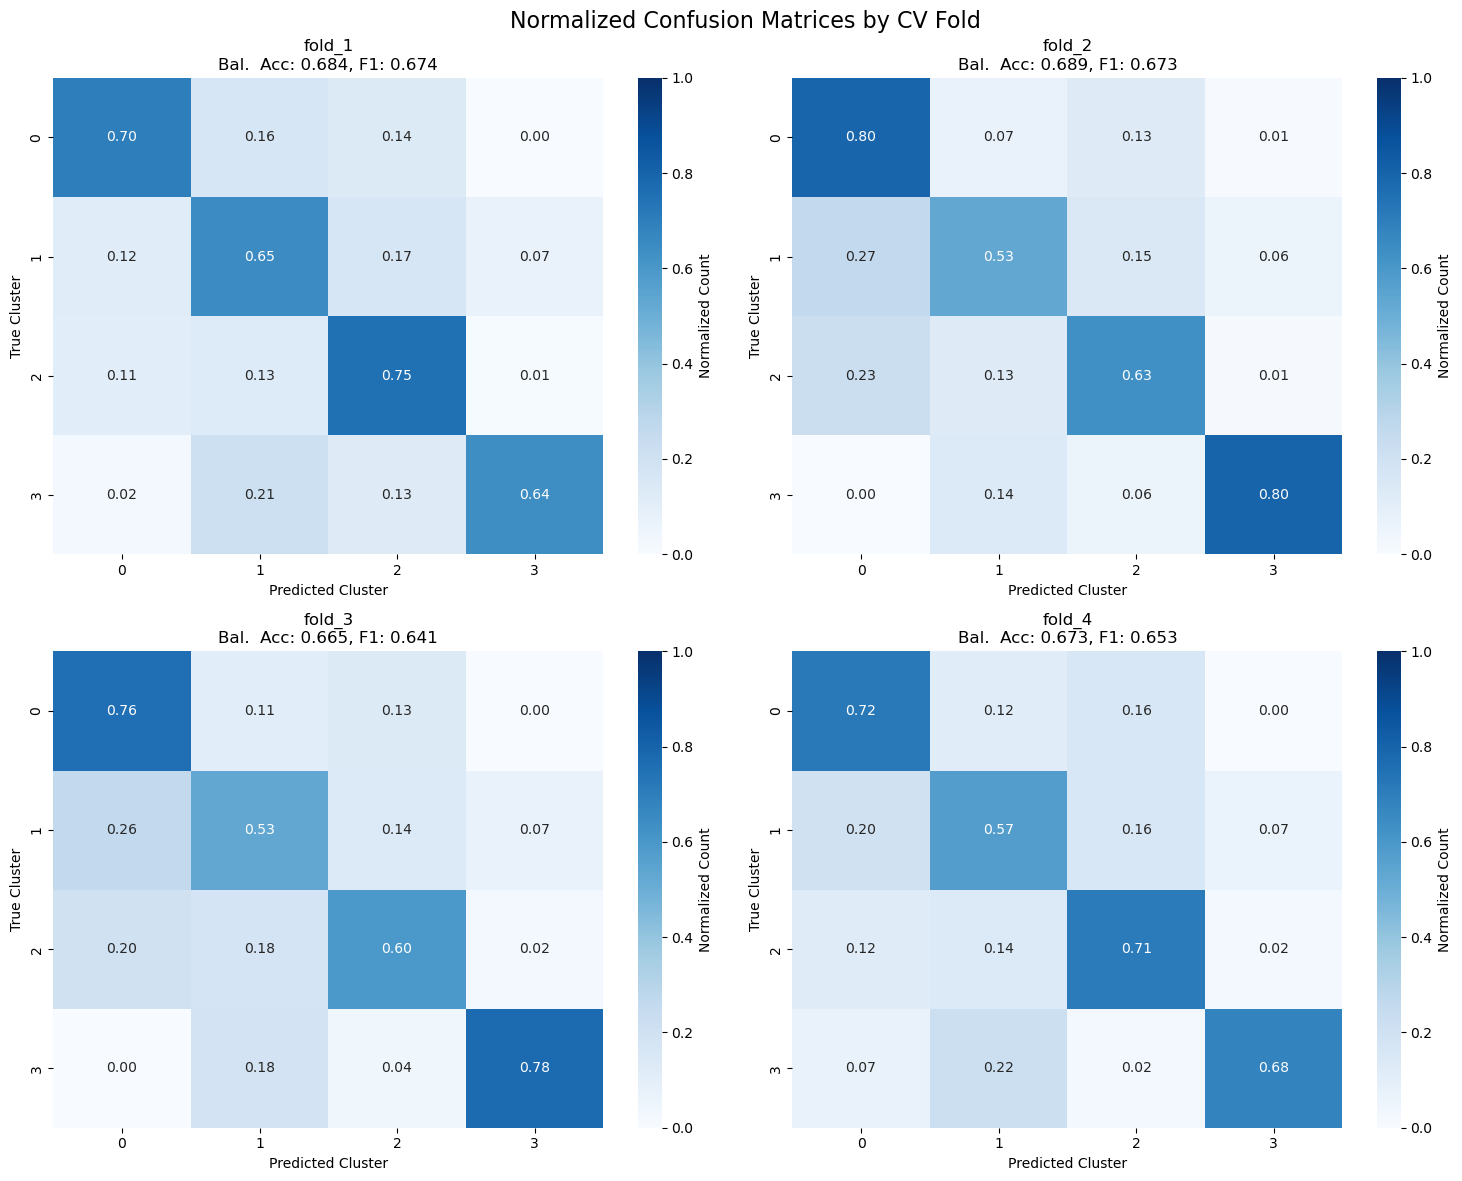


OVERALL CV SUMMARY
Mean Balanced Accuracy: 0.678 ± 0.010
Mean Macro F1: 0.660 ± 0.014

Pipeline completed successfully!


In [17]:
# 1. Run your baseline pipeline first
classifier = HeatmapCNNClassifier() 
classifier.run_full_pipeline()

### Functions for Ray Tune optuna tuning

In [10]:
######################## Complete Pure Optuna CNN Optimization ###############################

import optuna
import numpy as np
import pandas as pd
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Dropout, Flatten, Dense
from sklearn.metrics import balanced_accuracy_score, f1_score
import uuid
import gc

######################## Optimized CNN model creation for Optuna ###############################

def create_optuna_cnn_model(self, input_shape, config):
    """Create CNN model with Optuna-optimized hyperparameters"""
    
    print(f"Creating Optuna CNN model with input shape: {input_shape}")
    
    model = Sequential([
        # Input layer with optimized noise augmentation
        BlockGaussianNoise(config["noise_level"], config["block_size"], seed=42, input_shape=input_shape),

        # First convolutional block with optimized filters
        Conv2D(config["conv_filters_1"], (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(config["conv_filters_1"], (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Dropout(config["dropout_rate_conv"]),
        
        # Second convolutional block with optimized filters
        Conv2D(config["conv_filters_2"], (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(config["conv_filters_2"], (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Dropout(config["dropout_rate_conv"]),
        
        # Third convolutional block with optimized filters
        Conv2D(config["conv_filters_3"], (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(config["conv_filters_3"], (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Dropout(config["dropout_rate_conv"]),
        
        # Fully connected layers with optimized sizes
        Flatten(),
        Dense(config["dense_units_1"], activation='relu'),
        BatchNormalization(),
        Dropout(config["dropout_rate_dense"]),

        Dense(config["dense_units_2"], activation='relu'),
        Dropout(config["dropout_rate_dense"]),

        Dense(self.n_classes, activation='softmax')
    ])
    
    return model

# Add to class
HeatmapCNNClassifier.create_optuna_cnn_model = create_optuna_cnn_model

######################## Pure Optuna optimization function ###############################

def optimize_cnn_with_optuna(self, num_trials=30, max_epochs=25, cv_fold=None, timeout_minutes=60):
    """
    Pure Optuna CNN hyperparameter optimization
    
    Parameters:
    -----------
    num_trials : int
        Number of trials to run
    max_epochs : int
        Maximum epochs per trial
    cv_fold : str or None
        Specific CV fold to use, or None for first fold
    timeout_minutes : int
        Maximum time to run optimization (in minutes)
    """
    
    print("🎯 Starting Pure Optuna CNN Optimization...")
    print(f"  Trials: {num_trials}")
    print(f"  Max epochs per trial: {max_epochs}")
    print(f"  Timeout: {timeout_minutes} minutes")
    
    # Prepare data
    if not hasattr(self, 'fold_balanced_data') or not self.fold_balanced_data:
        raise ValueError("No fold_balanced_data found.  Run the full pipeline first.")
    
    # Select fold for optimization
    if cv_fold is None:
        fold_key = list(self.fold_balanced_data.keys())[0]
    else:
        fold_key = cv_fold
        if fold_key not in self.fold_balanced_data:
            raise ValueError(f"Fold {cv_fold} not found.  Available:  {list(self.fold_balanced_data.keys())}")
    
    fold_data = self.fold_balanced_data[fold_key]
    
    X_train = fold_data['X_train_scaled']
    y_train = fold_data['y_train']
    X_val = fold_data['X_val_scaled']
    y_val = fold_data['y_val']
    
    print(f"Using fold:  {fold_key}")
    print(f"Training data:  {X_train.shape}")
    print(f"Validation data: {X_val.shape}")
    print(f"Number of classes: {self.n_classes}")
    
    # Convert labels to categorical
    y_train_cat = to_categorical(y_train, self.n_classes)
    y_val_cat = to_categorical(y_val, self.n_classes)
    
    # Define Optuna objective function
    def objective(trial):
        """Optuna objective function for CNN hyperparameter optimization"""
        
        trial_num = trial.number + 1
        print(f"\n🔬 Trial {trial_num}/{num_trials}")
        
        # Suggest hyperparameters
        config = {
            # Core training parameters
            "learning_rate":  trial.suggest_float("learning_rate", 1e-5, 1e-2, log=True),
            "batch_size": trial.suggest_categorical("batch_size", [16, 32, 64, 128]),
            
            # Dropout parameters
            "dropout_rate_conv": trial.suggest_float("dropout_rate_conv", 0.1, 0.5),
            "dropout_rate_dense": trial.suggest_float("dropout_rate_dense", 0.3, 0.7),
            
            # Architecture parameters - Conv layers
            "conv_filters_1": trial.suggest_categorical("conv_filters_1", [16, 24, 32, 48]),
            "conv_filters_2":  trial.suggest_categorical("conv_filters_2", [32, 48, 64, 96]),
            "conv_filters_3": trial.suggest_categorical("conv_filters_3", [64, 96, 128, 192]),
            
            # Architecture parameters - Dense layers
            "dense_units_1": trial.suggest_categorical("dense_units_1", [256, 384, 512, 768]),
            "dense_units_2": trial.suggest_categorical("dense_units_2", [128, 192, 256, 384]),
            
            # Augmentation parameters
            "noise_level": trial.suggest_float("noise_level", 0.01, 0.15),
            "block_size":  trial.suggest_categorical("block_size", [2, 3, 4]),
            
            # Learning rate schedule parameters
            "lr_reduction_factor": trial.suggest_float("lr_reduction_factor", 0.3, 0.7),
            "lr_patience": trial.suggest_categorical("lr_patience", [3, 5, 7, 10]),
            "early_stop_patience": trial.suggest_categorical("early_stop_patience", [8, 10, 12, 15]),
        }
        
        print(f"  LR: {config['learning_rate']:.6f}")
        print(f"  Batch size: {config['batch_size']}")
        print(f"  Conv filters: [{config['conv_filters_1']}, {config['conv_filters_2']}, {config['conv_filters_3']}]")
        print(f"  Dense units: [{config['dense_units_1']}, {config['dense_units_2']}]")
        print(f"  Dropout:  Conv={config['dropout_rate_conv']:.3f}, Dense={config['dropout_rate_dense']:.3f}")
        
        try:
            # Create model with current configuration
            model = self.create_optuna_cnn_model(X_train.shape[1:], config)
            
            # Compile model with suggested parameters
            optimizer = Adam(learning_rate=config["learning_rate"])
            model.compile(
                optimizer=optimizer,
                loss='categorical_crossentropy',
                metrics=['accuracy']
            )
            
            # Setup callbacks with suggested parameters
            callbacks = [
                EarlyStopping(
                    monitor='val_loss',
                    patience=config["early_stop_patience"],
                    restore_best_weights=True,
                    verbose=0
                ),
                ReduceLROnPlateau(
                    monitor='val_loss',
                    factor=config["lr_reduction_factor"],
                    patience=config["lr_patience"],
                    min_lr=1e-7,
                    verbose=0
                )
            ]
            
            # Train model
            print(f"  Training for up to {max_epochs} epochs...")
            history = model.fit(
                X_train, y_train_cat,
                validation_data=(X_val, y_val_cat),
                epochs=max_epochs,
                batch_size=config["batch_size"],
                callbacks=callbacks,
                verbose=0
            )
            
            # Calculate metrics
            if len(history.history['val_loss']) == 0:
                print(f"  ❌ No training history available")
                return 0.0
            
            # Get predictions
            y_pred_proba = model.predict(X_val, verbose=0)
            y_pred = np.argmax(y_pred_proba, axis=1)
            
            # Calculate performance metrics
            balanced_acc = balanced_accuracy_score(y_val, y_pred)
            macro_f1 = f1_score(y_val, y_pred, average='macro')
            best_val_loss = min(history.history['val_loss'])
            epochs_trained = len(history.history['loss'])
            
            # Calculate overfitting metric
            final_train_loss = history.history['loss'][-1]
            final_val_loss = history.history['val_loss'][-1]
            overfitting_gap = final_val_loss - final_train_loss
            
            print(f"  ✅ Results:  Acc={balanced_acc:.4f}, F1={macro_f1:.4f}, Loss={best_val_loss:.4f}")
            print(f"     Epochs:  {epochs_trained}, Overfitting gap: {overfitting_gap:.4f}")
            
            # Store additional metrics in trial user attributes for later analysis
            trial.set_user_attr('macro_f1', macro_f1)
            trial.set_user_attr('val_loss', best_val_loss)
            trial.set_user_attr('epochs_trained', epochs_trained)
            trial.set_user_attr('overfitting_gap', overfitting_gap)
            
            # Cleanup model to free memory
            del model
            gc.collect()
            
            # Return balanced accuracy as the optimization target
            return balanced_acc
            
        except Exception as e: 
            print(f"  ❌ Trial failed: {str(e)}")
            # Cleanup in case of error
            try:
                del model
                gc.collect()
            except:
                pass
            return 0.0
    
    # Create and configure Optuna study
    study_name = f'cnn_optimization_{uuid.uuid4().hex[:8]}'
    
    # Use MedianPruner to stop unpromising trials early
    pruner = optuna.pruners.MedianPruner(
        n_startup_trials=5,      # Don't prune first 5 trials
        n_warmup_steps=5,        # Wait 5 steps before starting to prune
        interval_steps=2         # Check every 2 steps
    )
    
    study = optuna.create_study(
        direction='maximize',
        study_name=study_name,
        storage=None,  # In-memory storage
        pruner=pruner
    )
    
    print(f"\n🚀 Starting optimization study: {study_name}")
    
    # Run optimization
    try:
        study.optimize(
            objective, 
            n_trials=num_trials,
            timeout=timeout_minutes * 60,  # Convert to seconds
            show_progress_bar=True,
            gc_after_trial=True  # Force garbage collection after each trial
        )
        
    except KeyboardInterrupt:
        print("\n⚠️  Optimization interrupted by user")
    except Exception as e:
        print(f"\n❌ Optimization failed: {e}")
        return None, None
    
    # Analyze results
    print(f"\n📊 OPTIMIZATION COMPLETED")
    print(f"  Completed trials: {len(study.trials)}")
    print(f"  Pruned trials: {len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])}")
    print(f"  Failed trials: {len([t for t in study.trials if t.state == optuna.trial.TrialState.FAIL])}")
    
    if study.best_trial is None:
        print("❌ No successful trials found")
        return None, None
    
    # Get best results
    best_trial = study. best_trial
    best_params = best_trial.params
    best_score = best_trial.value
    
    print(f"\n🏆 BEST CONFIGURATION FOUND:")
    print(f"  Balanced Accuracy: {best_score:.4f}")
    if 'macro_f1' in best_trial.user_attrs:
        print(f"  Macro F1: {best_trial.user_attrs['macro_f1']:.4f}")
        print(f"  Validation Loss: {best_trial.user_attrs['val_loss']:.4f}")
        print(f"  Epochs Trained: {best_trial.user_attrs['epochs_trained']}")
        print(f"  Overfitting Gap: {best_trial.user_attrs['overfitting_gap']:.4f}")
    
    print(f"\n🎯 OPTIMIZED HYPERPARAMETERS:")
    for key, value in best_params. items():
        print(f"  {key}: {value}")
    
    # Show parameter importance
    if len(study.trials) >= 10:  # Need enough trials for importance analysis
        try:
            importance = optuna.importance.get_param_importances(study)
            print(f"\n📈 PARAMETER IMPORTANCE (top 5):")
            for param, imp in sorted(importance.items(), key=lambda x: x[1], reverse=True)[:5]:
                print(f"  {param}: {imp:.3f}")
        except Exception as e:
            print(f"  Could not calculate parameter importance: {e}")
    
    # Show top 5 trials
    successful_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    if len(successful_trials) >= 5:
        top_trials = sorted(successful_trials, key=lambda t: t.value or 0, reverse=True)[:5]
        print(f"\n🏅 TOP 5 TRIALS:")
        for i, trial in enumerate(top_trials):
            score = trial.value or 0
            f1 = trial.user_attrs.get('macro_f1', 'N/A')
            epochs = trial.user_attrs.get('epochs_trained', 'N/A')
            print(f"  {i+1}. Trial #{trial.number}:  Acc={score:.4f}, F1={f1}, Epochs={epochs}")
    
    # Store results in classifier
    self.optuna_study = study
    self.best_optuna_params = best_params
    self.best_optuna_config = best_params  # For compatibility
    
    print(f"\n✅ Optimization complete!  Use train_with_optuna_config() to apply results.")
    
    return best_params, study

######################## Function to apply optimized parameters ###############################

def train_with_optuna_config(self, config=None, run_full_cv=True):
    """Train model with Optuna-optimized hyperparameters"""
    
    if config is None:
        if not hasattr(self, 'best_optuna_params'):
            raise ValueError("No optimized parameters found. Run optimize_cnn_with_optuna() first.")
        config = self.best_optuna_params
    
    print("🚀 Training CNN with Optuna-optimized hyperparameters...")
    
    # Display the configuration
    print("\nOptimized configuration:")
    for key, value in config.items():
        print(f"  {key}: {value}")
    
    # Update global parameters for cross-validation
    global learning_rate, dropout_rate_conv, dropout_rate_dense, batch_size
    global noise_level, block_size, patience
    
    learning_rate = config["learning_rate"]
    dropout_rate_conv = config["dropout_rate_conv"]
    dropout_rate_dense = config["dropout_rate_dense"]
    batch_size = config["batch_size"]
    noise_level = config["noise_level"]
    block_size = config["block_size"]
    patience = config["early_stop_patience"]
    
    # Store config for model creation
    self.current_optuna_config = config
    
    if run_full_cv:
        print("\nRunning optimized cross-validation...")
        self.cross_validate_with_optuna()
    else:
        print("Skipping cross-validation. Set run_full_cv=True to run CV.")

def cross_validate_with_optuna(self):
    """Cross-validation using Optuna-optimized hyperparameters"""
    
    print("Starting Optuna-optimized cross-validation...")
    
    unique_folds = list(self.fold_balanced_data.keys())
    print(f"Cross-validation folds: {unique_folds}")
    
    cv_results = {
        'balanced_accuracy': [],
        'macro_f1': [],
        'fold_predictions': [],
        'fold_true_labels': [],
        'train_loss': [],
        'train_accuracy': [],
        'val_loss': [],
        'val_accuracy': []
    }
    
    self.cv_fold_results_optuna = []
    
    for fold in unique_folds:
        print(f"\nProcessing fold: {fold}")
        
        fold_data = self.fold_balanced_data[fold]
        X_train_fold = fold_data['X_train_scaled']
        y_train_fold = fold_data['y_train']
        X_val_fold = fold_data['X_val_scaled']
        y_val_fold = fold_data['y_val']
        
        print(f"  Fold {fold} - Train: {len(X_train_fold)}, Val: {len(X_val_fold)}")
        
        # Convert to categorical
        y_train_fold_cat = to_categorical(y_train_fold, self.n_classes)
        y_val_fold_cat = to_categorical(y_val_fold, self.n_classes)
        
        # Create optimized model
        model = self.create_optuna_cnn_model(X_train_fold.shape[1:], self.current_optuna_config)
        
        # Compile with optimized parameters
        optimizer = Adam(learning_rate=self.current_optuna_config["learning_rate"])
        model.compile(
            optimizer=optimizer,
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
        
        # Setup optimized callbacks
        callbacks = [
            EarlyStopping(
                monitor='val_loss',
                patience=self.current_optuna_config["early_stop_patience"],
                restore_best_weights=True
            ),
            ReduceLROnPlateau(
                monitor='val_loss',
                factor=self.current_optuna_config["lr_reduction_factor"],
                patience=self.current_optuna_config["lr_patience"],
                min_lr=1e-7
            )
        ]
        
        # Train with optimized parameters
        history = model.fit(
            X_train_fold, y_train_fold_cat,
            validation_data=(X_val_fold, y_val_fold_cat),
            epochs=epochs,  # Use global epochs setting
            batch_size=self. current_optuna_config["batch_size"],
            callbacks=callbacks,
            verbose=verbose_val
        )
        
        # Extract metrics
        final_train_loss = history.history['loss'][-1]
        final_train_accuracy = history.history['accuracy'][-1]
        final_val_loss = history.history['val_loss'][-1]
        final_val_accuracy = history.history['val_accuracy'][-1]
        
        cv_results['train_loss'].append(final_train_loss)
        cv_results['train_accuracy'].append(final_train_accuracy)
        cv_results['val_loss'].append(final_val_loss)
        cv_results['val_accuracy'].append(final_val_accuracy)
        
        # Predictions and metrics
        y_pred_proba = model.predict(X_val_fold, verbose=verbose_val)
        y_pred = np.argmax(y_pred_proba, axis=1)
        
        bal_acc = balanced_accuracy_score(y_val_fold, y_pred)
        macro_f1 = f1_score(y_val_fold, y_pred, average='macro')
        
        cv_results['balanced_accuracy'].append(bal_acc)
        cv_results['macro_f1'].append(macro_f1)
        cv_results['fold_predictions'].extend(y_pred)
        cv_results['fold_true_labels'].extend(y_val_fold)
        
        # Training metrics
        y_train_pred_proba = model.predict(X_train_fold, verbose=verbose_val)
        y_train_pred = np.argmax(y_train_pred_proba, axis=1)
        train_bal_acc = balanced_accuracy_score(y_train_fold, y_train_pred)
        train_macro_f1 = f1_score(y_train_fold, y_train_pred, average='macro')
        
        # Store fold results
        fold_result = {
            'fold_name': fold,
            'y_true': y_val_fold,
            'y_pred':  y_pred,
            'balanced_accuracy': bal_acc,
            'macro_f1': macro_f1,
            'n_samples': len(y_val_fold),
            'train_loss': final_train_loss,
            'train_accuracy': final_train_accuracy,
            'train_balanced_accuracy': train_bal_acc,
            'train_macro_f1': train_macro_f1,
            'val_loss': final_val_loss,
            'val_accuracy': final_val_accuracy
        }
        self.cv_fold_results_optuna.append(fold_result)
        
        print(f"  Results - Train: Loss={final_train_loss:.4f}, Acc={final_train_accuracy:.4f}")
        print(f"           Val: Loss={final_val_loss:.4f}, Acc={bal_acc:.4f}, F1={macro_f1:.4f}")
    
    self.cv_results_optuna = cv_results
    self.print_optuna_cv_results()

def print_optuna_cv_results(self):
    """Print Optuna-optimized cross-validation results with comparison"""
    
    print("\n" + "="*80)
    print("OPTUNA-OPTIMIZED CROSS-VALIDATION RESULTS")
    print("="*80)
    
    # Calculate optimized metrics
    bal_acc_mean = np.mean(self. cv_results_optuna['balanced_accuracy'])
    bal_acc_std = np.std(self.cv_results_optuna['balanced_accuracy'])
    f1_mean = np.mean(self.cv_results_optuna['macro_f1'])
    f1_std = np.std(self.cv_results_optuna['macro_f1'])
    val_loss_mean = np.mean(self.cv_results_optuna['val_loss'])
    val_loss_std = np. std(self.cv_results_optuna['val_loss'])
    
    print("OPTUNA-OPTIMIZED METRICS:")
    print(f"  Balanced Accuracy:    {bal_acc_mean:.4f} ± {bal_acc_std:.4f}")
    print(f"  Macro F1 Score:      {f1_mean:.4f} ± {f1_std:.4f}")
    print(f"  Validation Loss:     {val_loss_mean:.4f} ± {val_loss_std:.4f}")
    
    # Compare with baseline if available
    if hasattr(self, 'cv_results'):
        baseline_bal_acc = np.mean(self.cv_results['balanced_accuracy'])
        baseline_f1 = np.mean(self.cv_results['macro_f1'])
        baseline_loss = np.mean(self.cv_results['val_loss'])
        
        print(f"\n📈 IMPROVEMENT OVER BASELINE:")
        acc_improvement = bal_acc_mean - baseline_bal_acc
        f1_improvement = f1_mean - baseline_f1
        loss_improvement = baseline_loss - val_loss_mean  # Lower loss is better
        
        print(f"  Balanced Accuracy:  {bal_acc_mean:.4f} vs {baseline_bal_acc:.4f} ({acc_improvement:+.4f})")
        print(f"  Macro F1 Score:      {f1_mean:.4f} vs {baseline_f1:.4f} ({f1_improvement:+.4f})")
        print(f"  Validation Loss:    {val_loss_mean:.4f} vs {baseline_loss:.4f} ({loss_improvement:+.4f})")
        
        if acc_improvement > 0:
            print("  ✅ Accuracy improved!")
        if f1_improvement > 0:
            print("  ✅ F1 score improved!")
        if loss_improvement > 0:
            print("  ✅ Loss improved!")
    
    # Per-fold breakdown
    print(f"\nPER-FOLD RESULTS:")
    print("Fold      | Bal Acc | F1 Score | Val Loss | Epochs")
    print("-" * 50)
    for fold_result in self.cv_fold_results_optuna:
        fold_name = fold_result['fold_name']
        bal_acc = fold_result['balanced_accuracy']
        f1 = fold_result['macro_f1']
        val_loss = fold_result['val_loss']
        print(f"{fold_name:<9} | {bal_acc:.4f}  | {f1:.4f}   | {val_loss:.4f}  |")

# Add all functions to the class
HeatmapCNNClassifier.create_optuna_cnn_model = create_optuna_cnn_model
HeatmapCNNClassifier.optimize_cnn_with_optuna = optimize_cnn_with_optuna
HeatmapCNNClassifier.train_with_optuna_config = train_with_optuna_config
HeatmapCNNClassifier.cross_validate_with_optuna = cross_validate_with_optuna
HeatmapCNNClassifier.print_optuna_cv_results = print_optuna_cv_results

######################## Ready to run - Usage Example ###############################

print("✅ Pure Optuna CNN optimization loaded!")
print("\n🚀 Ready to optimize your CNN!")
print("\nTo run optimization:")
print("  best_params, study = classifier.optimize_cnn_with_optuna()")
print("\nTo train with optimized parameters:")
print("  classifier.train_with_optuna_config()")

# You can now run: 
# best_params, study = classifier.optimize_cnn_with_optuna(num_trials=30, max_epochs=25)
# classifier.train_with_optuna_config()

✅ Pure Optuna CNN optimization loaded!

🚀 Ready to optimize your CNN!

To run optimization:
  best_params, study = classifier.optimize_cnn_with_optuna()

To train with optimized parameters:
  classifier.train_with_optuna_config()


In [26]:
# Run the optimization (this will take a while)
best_params, study = classifier.optimize_cnn_with_optuna(
    num_trials=30,        # Number of different configurations to try
    max_epochs=25,        # Maximum epochs per trial
    timeout_minutes=120   # Stop after 2 hours max
)

[I 2026-01-07 14:04:52,925] A new study created in memory with name: cnn_optimization_594d2e43


🎯 Starting Pure Optuna CNN Optimization...
  Trials: 30
  Max epochs per trial: 25
  Timeout: 120 minutes
Using fold:  fold_1
Training data:  (3148, 46, 46, 3)
Validation data: (1063, 46, 46, 3)
Number of classes: 4

🚀 Starting optimization study: cnn_optimization_594d2e43


  0%|          | 0/30 [00:00<?, ?it/s]


🔬 Trial 1/30
  LR: 0.008759
  Batch size: 32
  Conv filters: [32, 32, 64]
  Dense units: [768, 384]
  Dropout:  Conv=0.399, Dense=0.397
Creating Optuna CNN model with input shape: (46, 46, 3)
  Training for up to 25 epochs...


  0%|          | 0/30 [01:10<?, ?it/s]

...


🔬 Trial 30/30
  LR: 0.003134
  Batch size: 32
  Conv filters: [32, 32, 64]
  Dense units: [768, 384]
  Dropout:  Conv=0.321, Dense=0.401
Creating Optuna CNN model with input shape: (46, 46, 3)
  Training for up to 25 epochs...


Best trial: 22. Best value: 0.702529:  97%|█████████▋| 29/30 [59:15<01:58, 118.21s/it, 3473.19/7200 seconds]

  ✅ Results:  Acc=0.6964, F1=0.6897, Loss=0.7661
     Epochs:  25, Overfitting gap: 0.2711
[I 2026-01-07 15:04:08,576] Trial 29 finished with value: 0.6963932940028517 and parameters: {'learning_rate': 0.003133633175256458, 'batch_size': 32, 'dropout_rate_conv': 0.32148237053464257, 'dropout_rate_dense': 0.4006642034855502, 'conv_filters_1': 32, 'conv_filters_2': 32, 'conv_filters_3': 64, 'dense_units_1': 768, 'dense_units_2': 384, 'noise_level': 0.13476114084285973, 'block_size': 3, 'lr_reduction_factor': 0.4407726704491698, 'lr_patience': 10, 'early_stop_patience': 15}. Best is trial 22 with value: 0.702529053767261.


Best trial: 22. Best value: 0.702529: 100%|██████████| 30/30 [59:16<00:00, 118.55s/it, 3556.36/7200 seconds]



📊 OPTIMIZATION COMPLETED
  Completed trials: 30
  Pruned trials: 0
  Failed trials: 0

🏆 BEST CONFIGURATION FOUND:
  Balanced Accuracy: 0.7025
  Macro F1: 0.6738
  Validation Loss: 0.7515
  Epochs Trained: 25
  Overfitting Gap: 0.2428

🎯 OPTIMIZED HYPERPARAMETERS:
  learning_rate: 0.0001992020152615974
  batch_size: 16
  dropout_rate_conv: 0.19513130555193567
  dropout_rate_dense: 0.43185696811710184
  conv_filters_1: 48
  conv_filters_2: 48
  conv_filters_3: 96
  dense_units_1: 384
  dense_units_2: 384
  noise_level: 0.13110381486571537
  block_size: 4
  lr_reduction_factor: 0.3969187716995002
  lr_patience: 3
  early_stop_patience: 10

📈 PARAMETER IMPORTANCE (top 5):
  learning_rate: 0.232
  lr_reduction_factor: 0.208
  batch_size: 0.114
  block_size: 0.112
  early_stop_patience: 0.101

🏅 TOP 5 TRIALS:
  1. Trial #22:  Acc=0.7025, F1=0.6738325684221207, Epochs=25
  2. Trial #29:  Acc=0.6964, F1=0.6896623652426838, Epochs=25
  3. Trial #4:  Acc=0.6963, F1=0.6840122499141494, Epochs=2

In [11]:
# 3. Train with optimized parameters
classifier.train_with_optuna_config(run_full_cv=True)

🚀 Training CNN with Optuna-optimized hyperparameters...

Optimized configuration:
  learning_rate: 0.0001992020152615974
  batch_size: 16
  dropout_rate_conv: 0.19513130555193567
  dropout_rate_dense: 0.43185696811710184
  conv_filters_1: 48
  conv_filters_2: 48
  conv_filters_3: 96
  dense_units_1: 384
  dense_units_2: 384
  noise_level: 0.13110381486571537
  block_size: 4
  lr_reduction_factor: 0.3969187716995002
  lr_patience: 3
  early_stop_patience: 10

Running optimized cross-validation...
Starting Optuna-optimized cross-validation...
Cross-validation folds: [np.str_('fold_1'), np.str_('fold_2'), np.str_('fold_3'), np.str_('fold_4')]

Processing fold: fold_1
  Fold fold_1 - Train: 3148, Val: 1063
Creating Optuna CNN model with input shape: (46, 46, 3)
Epoch 1/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.3564 - loss: 1.7022 - val_accuracy: 0.3321 - val_loss: 1.2248 - learning_rate: 1.9920e-04
Epoch 2/100
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.4498 -

In [ ]:
# Save the best configuration: 
import pickle
save_directory = '../Data/'
with open(save_directory + 'optimal_config.pkl', 'wb') as f:
    pickle.dump(classifier.best_optuna_params, f)

# Train full model and evaluate on test set

In [ ]:
######################## Fixed Version - Proper Class Methods ###############################

import pickle
import numpy as np
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, f1_score, classification_report, confusion_matrix

def verify_saved_config(self, config_path="../Data/optimal_config.pkl"):
    """
    Verify and display the contents of saved configuration
    """
    
    print(f"🔍 Verifying saved configuration:  {config_path}")
    
    try:
        with open(config_path, 'rb') as f:
            config = pickle.load(f)
        
        print("✅ Configuration file loaded successfully!")
        print(f"📊 Configuration contains {len(config)} parameters:")
        print()
        
        for key, value in config.items():
            print(f"  {key:<20}: {value}")
        
        # Check for required parameters
        required_params = [
            'learning_rate', 'batch_size', 'dropout_rate_conv', 'dropout_rate_dense',
            'conv_filters_1', 'conv_filters_2', 'conv_filters_3', 
            'dense_units_1', 'dense_units_2', 'noise_level', 'block_size',
            'lr_reduction_factor', 'lr_patience', 'early_stop_patience'
        ]
        
        missing_params = [param for param in required_params if param not in config]
        
        if missing_params:
            print(f"\n⚠️ Missing parameters:  {missing_params}")
        else:
            print(f"\n✅ All required parameters present!")
        
        return config
        
    except FileNotFoundError:
        print(f"❌ File not found: {config_path}")
        return None
    except Exception as e: 
        print(f"❌ Error reading file: {e}")
        return None

def train_and_evaluate_with_saved_config(self, config_path="../Data/optimal_config.pkl", 
                                        use_full_training=True, verbose=True, 
                                        max_epochs=100):
    """
    Train model with saved optimized hyperparameters and evaluate on test set
    """
    
    print("🚀 Training model with saved optimal configuration...")
    
    # Step 1: Load configuration from saved file
    print(f"\n📁 Loading configuration from: {config_path}")
    
    try:
        with open(config_path, 'rb') as f:
            config = pickle.load(f)
        print("✅ Configuration loaded successfully!")
    except FileNotFoundError:
        print(f"❌ Configuration file not found: {config_path}")
        print("Make sure the file exists and path is correct.")
        return None
    except Exception as e:
        print(f"❌ Error loading configuration: {e}")
        return None
    
    if verbose:
        print("\n📋 Using optimized configuration:")
        for key, value in config.items():
            print(f"  {key}:  {value}")
    
    # Store configuration for later use
    self.best_optuna_params = config
    
    # Step 2: Prepare training data
    if use_full_training:
        # Combine all training folds for maximum training data
        print("\n📊 Preparing combined training data from all CV folds...")
        
        if not hasattr(self, 'fold_balanced_data') or not self.fold_balanced_data:
            raise ValueError("No fold_balanced_data found.  Please run data preparation pipeline first.")
        
        X_train_combined = []
        y_train_combined = []
        
        for fold_name, fold_data in self.fold_balanced_data.items():
            X_train_combined.append(fold_data['X_train_scaled'])
            y_train_combined.append(fold_data['y_train'])
            print(f"  Fold {fold_name}: {len(fold_data['X_train_scaled'])} samples")
        
        X_train_final = np.vstack(X_train_combined)
        y_train_final = np.concatenate(y_train_combined)
        
        print(f"📈 Combined training data:  {X_train_final.shape}")
        
    else:
        # Use single fold (first fold) 
        first_fold = list(self.fold_balanced_data.keys())[0]
        fold_data = self.fold_balanced_data[first_fold]
        X_train_final = fold_data['X_train_scaled']
        y_train_final = fold_data['y_train']
        print(f"📈 Using single fold training data: {X_train_final.shape}")
    
    # Step 3: Prepare test data
    if not hasattr(self, 'X_test_scaled') or not hasattr(self, 'y_test_encoded'):
        raise ValueError("No test data found. Make sure you ran the full pipeline with train/test split.")
    
    X_test = self.X_test_scaled
    y_test = self.y_test_encoded
    
    print(f"📊 Test data: {X_test.shape}")
    print(f"📊 Number of classes: {self.n_classes}")
    
    # Print training class distribution
    print(f"\n📋 Training classes distribution:")
    for i, class_name in enumerate(self.label_encoder.classes_):
        count = np.sum(y_train_final == i)
        percentage = (count / len(y_train_final)) * 100
        print(f"  {class_name}: {count} samples ({percentage:.1f}%)")
    
    # Step 4: Convert to categorical
    y_train_final_cat = to_categorical(y_train_final, self.n_classes)
    y_test_cat = to_categorical(y_test, self.n_classes)
    
    print(f"\n🏗️ Building optimized model...")
    
    # Step 5: Create model with optimized architecture
    model = self.create_optuna_cnn_model(X_train_final.shape[1:], config)
    
    # Compile with optimized parameters
    optimizer = Adam(learning_rate=config["learning_rate"])
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    if verbose:
        print("\n🏛️ Model architecture summary:")
        model.summary()
    
    # Step 6: Setup optimized callbacks
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=config["early_stop_patience"],
            restore_best_weights=True,
            verbose=1 if verbose else 0
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=config["lr_reduction_factor"],
            patience=config["lr_patience"],
            min_lr=1e-7,
            verbose=1 if verbose else 0
        )
    ]
    
    # Step 7: Split training data for validation during training
    X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
        X_train_final, y_train_final_cat,
        test_size=0.15,  # Use 15% for validation during training
        random_state=42,
        stratify=y_train_final
    )
    
    print(f"\n🔥 Training model...")
    print(f"  Training set: {X_train_split.shape}")
    print(f"  Validation set: {X_val_split.shape}")
    print(f"  Test set: {X_test.shape}")
    print(f"  Max epochs: {max_epochs}")
    print(f"  Batch size:  {config['batch_size']}")
    print(f"  Learning rate: {config['learning_rate']:.6f}")
    
    # Step 8: Train model
    history = model.fit(
        X_train_split, y_train_split,
        validation_data=(X_val_split, y_val_split),
        epochs=max_epochs,
        batch_size=config["batch_size"],
        callbacks=callbacks,
        verbose=1 if verbose else 0
    )
    
    epochs_trained = len(history.history['loss'])
    print(f"\n📊 Training completed after {epochs_trained} epochs")
    
    # Step 9: Evaluate on test set
    print(f"\n🎯 Evaluating on test set...")
    
    # Test set predictions
    test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
    y_test_pred_proba = model.predict(X_test, verbose=0)
    y_test_pred = np.argmax(y_test_pred_proba, axis=1)
    
    # Calculate comprehensive test metrics
    test_balanced_acc = balanced_accuracy_score(y_test, y_test_pred)
    test_macro_f1 = f1_score(y_test, y_test_pred, average='macro')
    test_micro_f1 = f1_score(y_test, y_test_pred, average='micro')
    
    # Per-class metrics
    test_report = classification_report(
        y_test, y_test_pred,
        target_names=self.label_encoder.classes_,
        output_dict=True
    )
    
    test_cm = confusion_matrix(y_test, y_test_pred)
    
    # Store results
    self.test_results_optimized = {
        'model':  model,
        'history': history,
        'test_loss': test_loss,
        'test_accuracy': test_accuracy,
        'test_balanced_accuracy': test_balanced_acc,
        'test_macro_f1': test_macro_f1,
        'test_micro_f1': test_micro_f1,
        'y_true': y_test,
        'y_pred': y_test_pred,
        'y_pred_proba': y_test_pred_proba,
        'classification_report': test_report,
        'confusion_matrix': test_cm,
        'config_used': config,
        'config_path_used': config_path,
        'epochs_trained': epochs_trained
    }
    
    # Step 10: Print results
    print(f"\n🏆 FINAL TEST SET RESULTS:")
    print(f"  Test Loss: {test_loss:.4f}")
    print(f"  Test Accuracy: {test_accuracy:.4f}")
    print(f"  Test Balanced Accuracy: {test_balanced_acc:.4f}")
    print(f"  Test Macro F1: {test_macro_f1:.4f}")
    print(f"  Test Micro F1: {test_micro_f1:.4f}")
    print(f"  Epochs Trained: {epochs_trained}")
    
    # Per-class performance
    print(f"\n📋 PER-CLASS PERFORMANCE ON TEST SET:")
    print("Class".ljust(15), "Precision".ljust(10), "Recall".ljust(10), "F1-Score".ljust(10), "Support")
    print("-" * 60)
    for class_name in self.label_encoder.classes_:
        metrics = test_report[class_name]
        print(f"{class_name}".ljust(15), 
              f"{metrics['precision']:.3f}".ljust(10),
              f"{metrics['recall']:.3f}".ljust(10), 
              f"{metrics['f1-score']:.3f}".ljust(10),
              f"{int(metrics['support'])}")
    
    print(f"\n✅ Model training and evaluation completed!")
    print(f"💾 Results stored in classifier.test_results_optimized")
    
    return self.test_results_optimized

# Add all functions to class properly
HeatmapCNNClassifier.verify_saved_config = verify_saved_config
HeatmapCNNClassifier.train_and_evaluate_with_saved_config = train_and_evaluate_with_saved_config

print("✅ Fixed training functions loaded as proper class methods!")
print("\nNow you can use:")
print("  config = classifier.verify_saved_config('../Data/optimal_config.pkl')")
print("  success = classifier.quick_train_for_shap_analysis()")
print("  aggregated_shap, plots = classifier.quick_shap_analysis_100_samples()")

✅ Fixed training functions loaded as proper class methods!

Now you can use:
  config = classifier.verify_saved_config('../Data/optimal_config.pkl')
  success = classifier.quick_train_for_shap_analysis()
  aggregated_shap, plots = classifier.quick_shap_analysis_100_samples()


In [20]:
classifier.verify_saved_config('../Data/optimal_config.pkl')

🔍 Verifying saved configuration:  ../Data/optimal_config.pkl
✅ Configuration file loaded successfully!
📊 Configuration contains 14 parameters:

  learning_rate       : 0.0001992020152615974
  batch_size          : 16
  dropout_rate_conv   : 0.19513130555193567
  dropout_rate_dense  : 0.43185696811710184
  conv_filters_1      : 48
  conv_filters_2      : 48
  conv_filters_3      : 96
  dense_units_1       : 384
  dense_units_2       : 384
  noise_level         : 0.13110381486571537
  block_size          : 4
  lr_reduction_factor : 0.3969187716995002
  lr_patience         : 3
  early_stop_patience : 10

✅ All required parameters present!


{'learning_rate': 0.0001992020152615974,
 'batch_size': 16,
 'dropout_rate_conv': 0.19513130555193567,
 'dropout_rate_dense': 0.43185696811710184,
 'conv_filters_1': 48,
 'conv_filters_2': 48,
 'conv_filters_3': 96,
 'dense_units_1': 384,
 'dense_units_2': 384,
 'noise_level': 0.13110381486571537,
 'block_size': 4,
 'lr_reduction_factor': 0.3969187716995002,
 'lr_patience': 3,
 'early_stop_patience': 10}

In [22]:
# Step 1: Train the full model with saved optimal configuration
print("🚀 Starting full model training and evaluation...")
test_results = classifier.train_and_evaluate_with_saved_config(
    config_path='../Data/optimal_config.pkl',
    use_full_training=True,  # Use all CV folds for maximum training data
    verbose=True,           # Show detailed output
    max_epochs=100          # Allow up to 100 epochs
)

🚀 Starting full model training and evaluation...
🚀 Training model with saved optimal configuration...

📁 Loading configuration from: ../Data/optimal_config.pkl
✅ Configuration loaded successfully!

📋 Using optimized configuration:
  learning_rate:  0.0001992020152615974
  batch_size:  16
  dropout_rate_conv:  0.19513130555193567
  dropout_rate_dense:  0.43185696811710184
  conv_filters_1:  48
  conv_filters_2:  48
  conv_filters_3:  96
  dense_units_1:  384
  dense_units_2:  384
  noise_level:  0.13110381486571537
  block_size:  4
  lr_reduction_factor:  0.3969187716995002
  lr_patience:  3
  early_stop_patience:  10

📊 Preparing combined training data from all CV folds...
  Fold fold_1: 3148 samples
  Fold fold_2: 3148 samples
  Fold fold_3: 3148 samples
  Fold fold_4: 3188 samples
📈 Combined training data:  (12632, 46, 46, 3)
📊 Test data: (1405, 46, 46, 3)
📊 Number of classes: 4

📋 Training classes distribution:
  0: 3158 samples (25.0%)
  1: 3158 samples (25.0%)
  2: 3158 samples (2

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block_gaussian_noise_1          │ (None, 46, 46, 3)      │             0 │
│ (BlockGaussianNoise)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 46, 46, 48)     │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 46, 46, 48)     │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 46, 46, 48)     │        20,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 23, 23, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 23, 23, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 23, 23, 48)     │        20,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 23, 23, 48)     │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 23, 23, 48)     │        20,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 11, 11, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 11, 11, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 11, 11, 96)     │        41,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 11, 11, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 11, 11, 96)     │        83,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 5, 5, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 384)            │       921,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 384)            │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 384)            │       147,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,261,972 (4.81 MB)

 Trainable params: 1,260,820 (4.81 MB)

 Non-trainable params: 1,152 (4.50 KB)


🔥 Training model...
  Training set: (10737, 46, 46, 3)
  Validation set: (1895, 46, 46, 3)
  Test set: (1405, 46, 46, 3)
  Max epochs: 100
  Batch size:  16
  Learning rate: 0.000199
Epoch 1/100
672/672 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.4354 - loss: 1.4318 - val_accuracy: 0.5488 - val_loss: 1.0140 - learning_rate: 1.9920e-04
Epoch 2/100
672/672 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.5541 - loss: 1.0904 - val_accuracy: 0.6090 - val_loss: 0.8932 - learning_rate: 1.9920e-04
Epoch 3/100
672/672 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.6043 - loss: 0.9430 - val_accuracy: 0.6438 - val_loss: 0.8140 - learning_rate: 1.9920e-04
Epoch 4/100
672/672 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - accuracy: 0.6493 - loss: 0.8363 - val_accuracy: 0.6939 - val_loss: 0.7128 - learning_rate: 1.9920e-04
Epoch 5/100
672/672 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - accuracy: 0.6760 - loss: 0.7693 - val_accuracy: 0.7483 - val_loss: 0.6085 - learning_rate: 1.9920e-04
Epoch 6/100
672/672 ━


📊 Creating comprehensive test result plots...


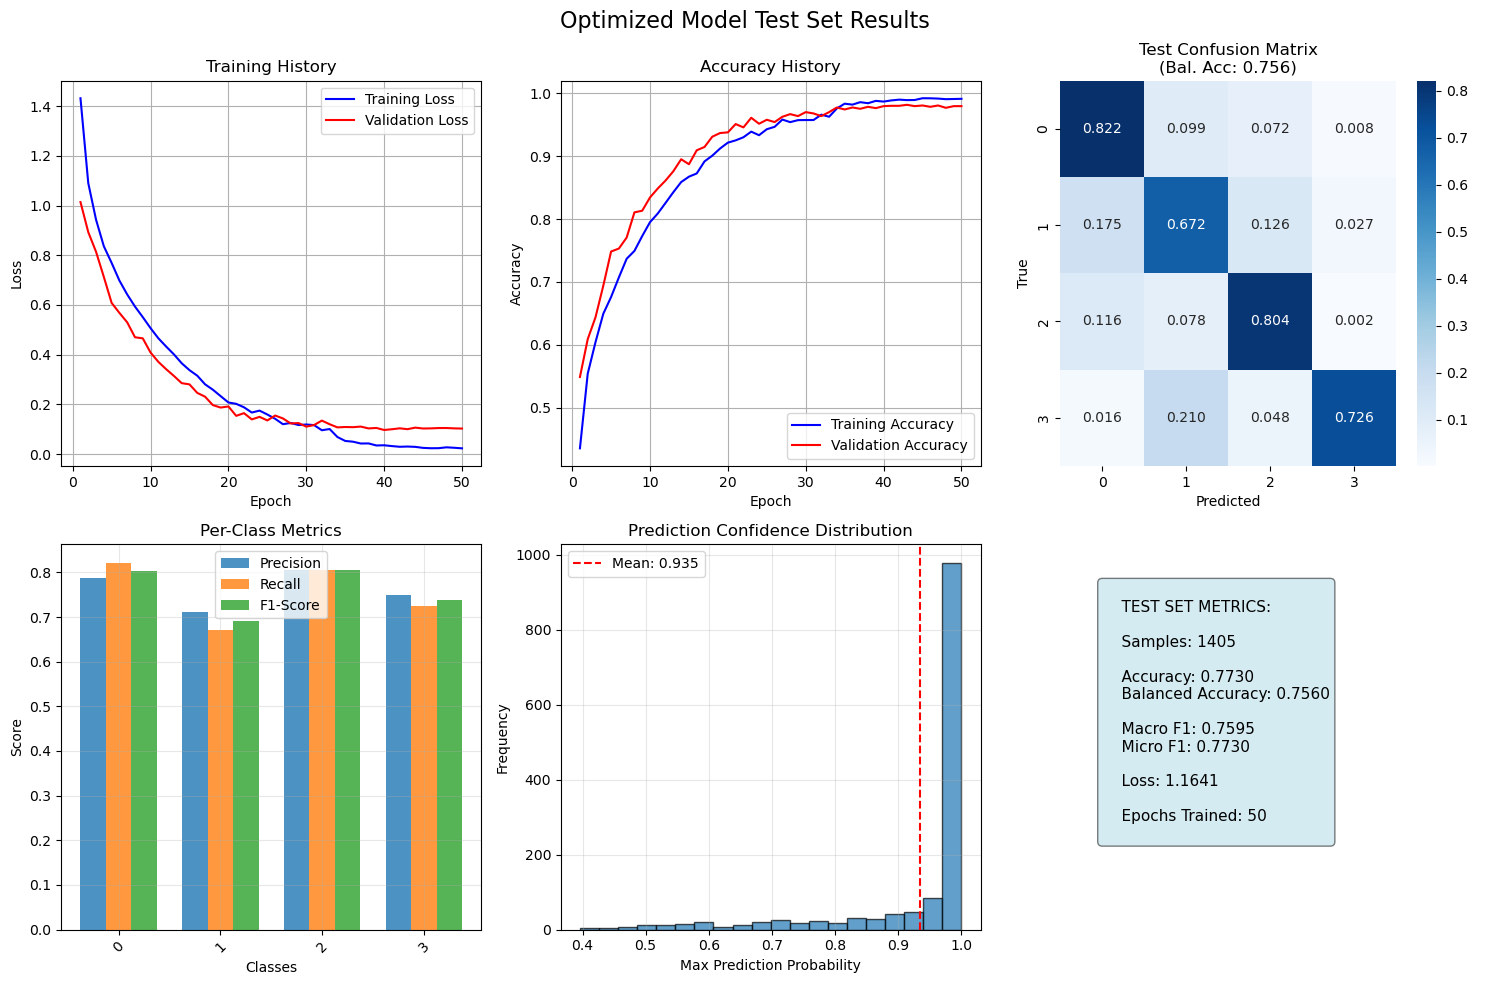

In [23]:
# Step 2: Plot comprehensive test results
print("\n📊 Creating comprehensive test result plots...")
classifier.plot_test_results(figsize=(15, 10))

In [24]:
# Step 3: Compare with baseline results (if available)
print("\n📈 Comparing with baseline results...")
classifier.compare_all_results()

print("\n✅ Full training and evaluation completed!")
print("📁 Results stored in classifier.test_results_optimized")
print("🎯 Ready for SHAP analysis in next step")


📈 Comparing with baseline results...

COMPREHENSIVE RESULTS COMPARISON
Method               Bal. Accuracy   Macro F1     Loss
------------------------------------------------------------
Optimized Test       0.7560          0.7595       1.1641

✅ Full training and evaluation completed!
📁 Results stored in classifier.test_results_optimized
🎯 Ready for SHAP analysis in next step


In [25]:
######################## Clean Model Save/Load - Simple Approach ###############################

import os
import pickle
import tensorflow as tf

def save_clean_model_for_shap(self, save_directory='../Data/', model_name='clean_optimized_model'):
    """
    Save model without BlockGaussianNoise layer for easy SHAP loading
    """
    
    if not hasattr(self, 'test_results_optimized') or 'model' not in self.test_results_optimized:
        print("❌ No trained model found.   Train the model first.")
        return False
    
    original_model = self.test_results_optimized['model']
    
    print(f"💾 Saving clean model (without custom layers) to {save_directory}...")
    
    # Create save directory if it doesn't exist
    os.makedirs(save_directory, exist_ok=True)
    
    try:
        # Step 1: Create clean model without BlockGaussianNoise
        print("🛠️ Creating clean model...")
        
        # Get input shape (remove batch dimension)
        input_shape = original_model.input_shape[1:]
        print(f"  Input shape: {input_shape}")
        
        # Create new input layer
        clean_input = tf.keras.layers.Input(shape=input_shape, name='clean_input')
        x = clean_input
        
        # Copy all layers except BlockGaussianNoise
        layers_copied = 0
        for i, layer in enumerate(original_model.layers):
            layer_name = layer.__class__.__name__
            
            # Skip BlockGaussianNoise layer
            if layer_name == 'BlockGaussianNoise': 
                print(f"  Skipping layer {i}: {layer_name}")
                continue
            
            try:
                # Apply layer to current tensor
                x = layer(x)
                layers_copied += 1
                print(f"  Copied layer {i}: {layer_name}")
            except Exception as e:
                print(f"  ⚠️ Could not copy layer {i} ({layer_name}): {e}")
                continue
        
        print(f"  ✅ Successfully copied {layers_copied} layers")
        
        # Step 2: Create clean model
        clean_model = tf.keras.Model(inputs=clean_input, outputs=x, name='clean_shap_model')
        
        # Compile clean model (simple compilation for SHAP)
        clean_model.compile(
            optimizer='adam',
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
        
        print(f"  📊 Clean model shape: {clean_model.input_shape} -> {clean_model.output_shape}")
        
        # Step 3: Test clean model
        print("🧪 Testing clean model...")
        dummy_input = tf.random.normal((1,) + input_shape)
        
        original_pred = original_model.predict(dummy_input, verbose=0)
        clean_pred = clean_model.predict(dummy_input, verbose=0)
        
        # Compare predictions (should be very similar since BlockGaussianNoise is off during inference)
        pred_diff = tf.reduce_max(tf.abs(original_pred - clean_pred)).numpy()
        print(f"  📊 Max prediction difference: {pred_diff:.8f}")
        
        if pred_diff < 0.001:
            print("  ✅ Clean model predictions match original")
        else:
            print("  ⚠️ Some difference in predictions (may be OK)")
        
        # Step 4: Save clean model
        clean_model_path = os.path.join(save_directory, f'{model_name}.h5')
        clean_model.save(clean_model_path)
        print(f"✅ Clean model saved:  {clean_model_path}")
        
        # Step 5: Save metadata
        metadata = {
            'model_name': model_name,
            'clean_model_path': clean_model_path,
            'original_config': self.test_results_optimized. get('config_used', {}),
            'original_performance': {
                'test_accuracy': self.test_results_optimized. get('test_accuracy', 0),
                'test_balanced_accuracy': self.test_results_optimized.get('test_balanced_accuracy', 0),
                'test_macro_f1': self.test_results_optimized.get('test_macro_f1', 0),
                'epochs_trained': self.test_results_optimized.get('epochs_trained', 0)
            },
            'input_shape': input_shape,
            'output_shape': clean_model.output_shape[1:],
            'n_classes': getattr(self, 'n_classes', 4),
            'label_encoder_classes': getattr(self. label_encoder, 'classes_', []).tolist() if hasattr(self, 'label_encoder') else []
        }
        
        metadata_path = os.path.join(save_directory, f'{model_name}_metadata.pkl')
        with open(metadata_path, 'wb') as f:
            pickle.dump(metadata, f)
        print(f"✅ Metadata saved: {metadata_path}")
        
        print(f"\n📁 CLEAN MODEL SAVED:")
        print(f"  Model file: {clean_model_path}")
        print(f"  Metadata file: {metadata_path}")
        print(f"  Ready for SHAP analysis!")
        
        return {
            'model_path': clean_model_path,
            'metadata_path':  metadata_path,
            'model':  clean_model
        }
        
    except Exception as e: 
        print(f"❌ Failed to create clean model: {e}")
        import traceback
        traceback.print_exc()
        return False

def load_clean_model_for_shap(self, save_directory='../Data/', model_name='clean_optimized_model'):
    """
    Load clean model for SHAP analysis (no custom layers)
    """
    
    print(f"📂 Loading clean model for SHAP analysis...")
    
    # Step 1: Load metadata
    metadata_path = os. path.join(save_directory, f'{model_name}_metadata.pkl')
    try:
        with open(metadata_path, 'rb') as f:
            metadata = pickle.load(f)
        print("✅ Metadata loaded")
        print(f"  Original performance:  Acc={metadata['original_performance']['test_balanced_accuracy']:.4f}")
    except Exception as e:
        print(f"⚠️ Could not load metadata: {e}")
        metadata = None
    
    # Step 2: Load clean model
    clean_model_path = os.path.join(save_directory, f'{model_name}.h5')
    
    try:
        model = tf.keras.models.load_model(clean_model_path)
        print(f"✅ Clean model loaded from:  {clean_model_path}")
        print(f"  📊 Model shape: {model.input_shape} -> {model.output_shape}")
        
        # Step 3: Store for SHAP analysis
        if not hasattr(self, 'test_results_optimized'):
            self.test_results_optimized = {}
        
        self.test_results_optimized['model'] = model
        
        # Store metadata if available
        if metadata:
            self.loaded_model_metadata = metadata
            # Restore label encoder if needed
            if metadata['label_encoder_classes'] and not hasattr(self, 'label_encoder'):
                from sklearn.preprocessing import LabelEncoder
                self.label_encoder = LabelEncoder()
                self.label_encoder.classes_ = np.array(metadata['label_encoder_classes'])
            
            # Restore n_classes
            if not hasattr(self, 'n_classes'):
                self.n_classes = metadata['n_classes']
        
        # Step 4: Test model
        print("🧪 Testing loaded model...")
        input_shape = model.input_shape[1:]
        dummy_input = tf.random.normal((1,) + input_shape)
        test_output = model.predict(dummy_input, verbose=0)
        
        print(f"  ✅ Model test successful")
        print(f"  📊 Output shape: {test_output.shape}")
        print(f"  📊 Output sum: {test_output.sum():.6f} (should be ~1. 0 for probabilities)")
        
        print(f"\n🎯 Model ready for SHAP analysis!")
        print(f"Use: aggregated_shap, plots = classifier.quick_shap_analysis_100_samples()")
        
        return True
        
    except FileNotFoundError:
        print(f"❌ Clean model file not found: {clean_model_path}")
        print(f"Make sure you saved the model first using save_clean_model_for_shap()")
        return False
    except Exception as e:
        print(f"❌ Failed to load clean model: {e}")
        import traceback
        traceback.print_exc()
        return False

def quick_save_and_load_workflow(self, save_directory='../Data/'):
    """
    Complete workflow: save clean model and immediately test loading
    """
    
    print("🔄 Complete save and load workflow...")
    
    # Save clean model
    save_result = self.save_clean_model_for_shap(save_directory=save_directory)
    
    if not save_result:
        print("❌ Save failed")
        return False
    
    print("\n" + "="*50)
    
    # Clear current model to test loading
    if hasattr(self, 'test_results_optimized'):
        original_model = self.test_results_optimized. get('model')
        del self.test_results_optimized['model']
    
    # Test loading
    load_success = self.load_clean_model_for_shap(save_directory=save_directory)
    
    if load_success: 
        print("\n✅ Complete workflow successful!")
        print("🎯 Model saved and loaded successfully - ready for SHAP!")
        return True
    else: 
        # Restore original model if loading failed
        if 'original_model' in locals():
            self.test_results_optimized['model'] = original_model
        print("❌ Loading failed")
        return False

# Add functions to class
HeatmapCNNClassifier.save_clean_model_for_shap = save_clean_model_for_shap
HeatmapCNNClassifier.load_clean_model_for_shap = load_clean_model_for_shap
HeatmapCNNClassifier.quick_save_and_load_workflow = quick_save_and_load_workflow

print("✅ Clean model save/load functions loaded!")
print("\nUsage:")
print("1. After training: save_result = classifier.save_clean_model_for_shap()")
print("2. Later for SHAP: success = classifier.load_clean_model_for_shap()")
print("3. Test workflow: classifier.quick_save_and_load_workflow()")

"""
# COMPLETE WORKFLOW: 

# After training your model:
save_result = classifier.save_clean_model_for_shap(
    save_directory='../Data/',
    model_name='clean_optimized_model'
)

# Later, in a new session, load for SHAP: 
success = classifier.load_clean_model_for_shap(
    save_directory='../Data/',
    model_name='clean_optimized_model'
)

# Run SHAP analysis: 
if success:
    aggregated_shap, plots = classifier. quick_shap_analysis_100_samples()
    classifier.analyze_quick_shap_patterns()
"""

✅ Clean model save/load functions loaded!

Usage:
1. After training: save_result = classifier.save_clean_model_for_shap()
2. Later for SHAP: success = classifier.load_clean_model_for_shap()
3. Test workflow: classifier.quick_save_and_load_workflow()


"\n# COMPLETE WORKFLOW: \n\n# After training your model:\nsave_result = classifier.save_clean_model_for_shap(\n    save_directory='../Data/',\n    model_name='clean_optimized_model'\n)\n\n# Later, in a new session, load for SHAP: \nsuccess = classifier.load_clean_model_for_shap(\n    save_directory='../Data/',\n    model_name='clean_optimized_model'\n)\n\n# Run SHAP analysis: \nif success:\n    aggregated_shap, plots = classifier. quick_shap_analysis_100_samples()\n    classifier.analyze_quick_shap_patterns()\n"

In [ ]:
save_result = classifier.save_clean_model_for_shap()
## Later for SHAP: 
# classifier.load_clean_model_for_shap()

💾 Saving clean model (without custom layers) to ../Data/...
🛠️ Creating clean model...
  Input shape: (46, 46, 3)
  Skipping layer 0: BlockGaussianNoise
  Copied layer 1: Conv2D
  Copied layer 2: BatchNormalization
  Copied layer 3: Conv2D
  Copied layer 4: MaxPooling2D
  Copied layer 5: Dropout
  Copied layer 6: Conv2D
  Copied layer 7: BatchNormalization
  Copied layer 8: Conv2D
  Copied layer 9: MaxPooling2D
  Copied layer 10: Dropout
  Copied layer 11: Conv2D
  Copied layer 12: BatchNormalization
  Copied layer 13: Conv2D
  Copied layer 14: MaxPooling2D
  Copied layer 15: Dropout
  Copied layer 16: Flatten
  Copied layer 17: Dense
  Copied layer 18: BatchNormalization
  Copied layer 19: Dropout
  Copied layer 20: Dense
  Copied layer 21: Dropout
  Copied layer 22: Dense
  ✅ Successfully copied 22 layers
  📊 Clean model shape: (None, 46, 46, 3) -> (None, 4)
🧪 Testing clean model...
  📊 Max prediction difference: 0.00000000
  ✅ Clean model predictions match original
✅ Clean model sav

# SHAP analysis

### SHAP analysis of final model

In [36]:
######################## Comprehensive SHAP Analysis with Clean Model Loading ###############################
import time
import os
import pickle
import numpy as np
import shap
import tensorflow as tf
from collections import Counter
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

######################## Optimized SHAP Analysis - Faster Version ###############################

def calculate_all_samples_shap_optimized(self, 
                                        model_directory='../Data/', 
                                        model_name='clean_optimized_model',
                                        background_samples=200,  # Reduced from 500
                                        batch_size=100,          # Increased from 50
                                        save_interval=5,         # Reduced from 10
                                        max_samples_per_cluster=1000,  # NEW: Limit samples
                                        random_state=42):
    """
    Optimized SHAP calculation with speed improvements
    """
    
    print("🚀 Starting OPTIMIZED SHAP Analysis")
    print("="*50)
    print(f"⚡ Optimizations:")
    print(f"  • Background samples: {background_samples} (reduced)")
    print(f"  • Batch size: {batch_size} (increased)")  
    print(f"  • Max samples per cluster: {max_samples_per_cluster}")
    print(f"  • Save interval:  {save_interval}")
    
    # Step 1: Create save directory
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    save_dir = f"../Data/shap_results_optimized_{timestamp}"
    os.makedirs(save_dir, exist_ok=True)
    
    print(f"📁 Save directory: {save_dir}")
    
    # Step 2: Load model
    print(f"\n🔄 Loading model...")
    load_success = self.load_clean_model_for_shap(model_directory, model_name)
    if not load_success:
        return None
    
    model = self.test_results_optimized['model']
    
    # Step 3: Prepare data with sampling
    X_all = np.concatenate([self.X_train_scaled, self.X_test_scaled], axis=0)
    y_all = np.concatenate([self.y_train_encoded, self.y_test_encoded], axis=0)
    
    print(f"📊 Total data:  {X_all.shape}")
    print(f"📊 Distribution: {Counter(y_all)}")
    
    # Step 4: Setup explainer with fewer background samples
    print(f"\n🧠 Setting up explainer with {background_samples} background samples...")
    np.random.seed(random_state)
    
    background_indices = np.random.choice(len(X_all), size=background_samples, replace=False)
    background_data = X_all[background_indices]
    
    explainer = shap.DeepExplainer(model, background_data)
    print("✅ Explainer ready")
    
    # Step 5: Process clusters with sampling
    all_results = {}
    
    for cluster_id in range(4):
        print(f"\n🔍 Processing Cluster {cluster_id}...")
        
        cluster_mask = y_all == cluster_id
        cluster_indices = np.where(cluster_mask)[0]
        
        if len(cluster_indices) == 0:
            continue
            
        # Sample if too many samples
        if len(cluster_indices) > max_samples_per_cluster:
            sampled_indices = np.random.choice(
                cluster_indices, 
                size=max_samples_per_cluster, 
                replace=False
            )
            cluster_samples = X_all[sampled_indices]
            print(f"  📊 Using {max_samples_per_cluster}/{len(cluster_indices)} samples (sampled)")
        else:
            cluster_samples = X_all[cluster_indices]
            print(f"  📊 Using all {len(cluster_samples)} samples")
        
        n_samples = len(cluster_samples)
        
        # Process in larger batches
        cluster_shap_values = []
        total_batches = (n_samples - 1) // batch_size + 1
        
        print(f"  🔄 Processing {total_batches} batches (size {batch_size})...")
        
        start_time = time.time()
        
        for batch_idx in range(0, n_samples, batch_size):
            batch_end = min(batch_idx + batch_size, n_samples)
            batch_samples = cluster_samples[batch_idx:batch_end]
            batch_number = batch_idx // batch_size + 1
            
            try:
                # Calculate SHAP values
                batch_shap = explainer.shap_values(batch_samples)
                
                if isinstance(batch_shap, list):
                    batch_shap_cluster = batch_shap[cluster_id]
                else:
                    batch_shap_cluster = batch_shap
                
                # Handle shape issues
                if len(batch_shap_cluster.shape) == 5:
                    batch_shap_cluster = batch_shap_cluster[: , :, :, : , cluster_id]
                
                cluster_shap_values.append(batch_shap_cluster)
                
                # Progress update
                if batch_number % save_interval == 0 or batch_number == total_batches:
                    elapsed = time.time() - start_time
                    progress = (batch_number / total_batches) * 100
                    rate = batch_number / elapsed * 60  # batches per minute
                    
                    print(f"    📈 Batch {batch_number}/{total_batches} ({progress:.1f}%) | "
                          f"Rate: {rate:.1f} batches/min | Elapsed: {elapsed/60:.1f}min")
                    
                    # Save checkpoint less frequently for speed
                    if batch_number % (save_interval * 2) == 0:
                        current_shap = np.concatenate(cluster_shap_values, axis=0)
                        checkpoint_data = {
                            'cluster_id': cluster_id,
                            'batch_num': batch_number,
                            'partial_shap': current_shap,
                            'progress': progress
                        }
                        
                        checkpoint_file = os.path.join(save_dir, f'checkpoint_c{cluster_id}_b{batch_number: 03d}.pkl')
                        with open(checkpoint_file, 'wb') as f:
                            pickle.dump(checkpoint_data, f)
                
            except Exception as e:
                print(f"    ❌ Batch {batch_number} failed: {e}")
                continue
        
        # Store results
        if cluster_shap_values:
            final_shap = np.concatenate(cluster_shap_values, axis=0)
            all_results[cluster_id] = {
                'shap_values':  final_shap,
                'n_samples': n_samples
            }
            
            elapsed = time.time() - start_time
            print(f"  ✅ Cluster {cluster_id} complete:  {elapsed/60:.1f}min | Shape: {final_shap.shape}")
    
    # Step 6: Aggregate and save
    print(f"\n📈 Aggregating results...")
    aggregated_shap = {}
    
    for cluster_id, data in all_results.items():
        aggregated = np.mean(data['shap_values'], axis=0)
        aggregated_shap[cluster_id] = aggregated
        print(f"  Cluster {cluster_id}: {aggregated.shape}")
    
    # Save final results
    final_results = {
        'aggregated_shap_values': aggregated_shap,
        'all_results': all_results,
        'metadata': {
            'timestamp': timestamp,
            'background_samples': background_samples,
            'batch_size': batch_size,
            'max_samples_per_cluster': max_samples_per_cluster,
            'total_samples_processed': sum(data['n_samples'] for data in all_results.values())
        }
    }
    
    # Save aggregated only (for plotting)
    aggregated_file = os.path.join(save_dir, f'aggregated_shap_optimized_{timestamp}.pkl')
    with open(aggregated_file, 'wb') as f:
        pickle.dump(aggregated_shap, f)
    
    # Save complete results
    complete_file = os.path.join(save_dir, f'complete_shap_optimized_{timestamp}.pkl')
    with open(complete_file, 'wb') as f:
        pickle.dump(final_results, f)
    
    print(f"\n🎉 OPTIMIZED SHAP ANALYSIS COMPLETED!")
    print(f"📁 Results saved in: {save_dir}")
    print(f"📊 Total samples processed: {sum(data['n_samples'] for data in all_results.values())}")
    
    return aggregated_shap, save_dir

def _save_backup_checkpoint(self, save_dir, cluster_id, batch_num, cluster_samples, 
                           partial_shap_values, metadata):
    """Save backup checkpoint every N batches"""
    
    checkpoint_data = {
        'cluster_id': cluster_id,
        'batch_num': batch_num,
        'cluster_samples': cluster_samples,
        'partial_shap_values': partial_shap_values,
        'metadata': metadata,
        'checkpoint_timestamp': datetime.now().isoformat()
    }
    
    checkpoint_file = os.path.join(save_dir, f'checkpoint_cluster_{cluster_id}_batch_{batch_num: 03d}.pkl')
    
    with open(checkpoint_file, 'wb') as f:
        pickle.dump(checkpoint_data, f, protocol=pickle.HIGHEST_PROTOCOL)
    
    file_size_mb = os.path.getsize(checkpoint_file) / 1024 / 1024
    progress = metadata['progress_percent']
    
    print(f"    💾 Checkpoint saved: batch {batch_num} ({progress:.1f}% complete, {file_size_mb:.1f} MB)")

def _save_cluster_complete(self, save_dir, cluster_id, cluster_data):
    """Save complete cluster results"""
    
    cluster_file = os.path.join(save_dir, f'cluster_{cluster_id}_complete.pkl')
    
    cluster_save_data = {
        'cluster_id': cluster_id,
        'samples': cluster_data['samples'],
        'shap_values': cluster_data['shap_values'],
        'sample_indices': cluster_data['sample_indices'],
        'n_samples': cluster_data['n_samples'],
        'completion_timestamp': datetime.now().isoformat()
    }
    
    with open(cluster_file, 'wb') as f:
        pickle.dump(cluster_save_data, f, protocol=pickle.HIGHEST_PROTOCOL)
    
    file_size_mb = os.path.getsize(cluster_file) / 1024 / 1024
    print(f"  💾 Complete cluster data saved: {cluster_file} ({file_size_mb:.1f} MB)")

def _save_analysis_summary(self, save_dir, timestamp, metadata, aggregated_shap_values):
    """Save human-readable summary"""
    
    summary_file = os.path.join(save_dir, f'shap_analysis_summary_{timestamp}.txt')
    
    with open(summary_file, 'w') as f:
        f.write("COMPREHENSIVE SHAP ANALYSIS SUMMARY\n")
        f.write("=" * 60 + "\n")
        f.write(f"Analysis Timestamp: {timestamp}\n")
        f.write(f"Completion Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"Model Used: {metadata['model_used']}\n")
        f.write(f"Background Samples:  {metadata['background_samples']}\n")
        f.write(f"Batch Size: {metadata['batch_size']}\n")
        f.write(f"Save Interval:  {metadata['save_interval']}\n")
        f.write(f"Total Samples: {metadata['total_samples']}\n\n")
        
        f.write("CLUSTER RESULTS:\n")
        for cluster_id, cluster_info in metadata['clusters_processed'].items():
            f.write(f"  Cluster {cluster_id}:\n")
            f.write(f"    Samples: {cluster_info['n_samples']}\n")
            f.write(f"    SHAP Shape: {cluster_info['shap_shape']}\n")
            f.write(f"    Value Range: {cluster_info['value_range']}\n")
            f.write(f"    Batches:  {cluster_info['batches_processed']}\n")
        
        f.write(f"\nAGGREGATED RESULTS:\n")
        for cluster_id, agg_shap in aggregated_shap_values.items():
            mean_abs_shap = np.abs(agg_shap).mean()
            max_abs_shap = np.abs(agg_shap).max()
            f.write(f"  Cluster {cluster_id}:\n")
            f.write(f"    Shape: {agg_shap.shape}\n")
            f.write(f"    Mean |SHAP|: {mean_abs_shap:.6f}\n")
            f.write(f"    Max |SHAP|: {max_abs_shap:.6f}\n")
        
        f.write(f"\nFILES CREATED:\n")
        f.write(f"  Main results:  complete_shap_results_{timestamp}.pkl\n")
        f.write(f"  Aggregated:  aggregated_shap_values_{timestamp}.pkl\n")
        f.write(f"  Checkpoints: checkpoint_cluster_*_batch_*.pkl\n")
        f.write(f"  Cluster files: cluster_*_complete.pkl\n")
        f.write(f"  Summary: {summary_file}\n")
    
    print(f"📝 Analysis summary saved:  {summary_file}")

# Add functions to class

HeatmapCNNClassifier._save_backup_checkpoint = _save_backup_checkpoint
HeatmapCNNClassifier._save_cluster_complete = _save_cluster_complete
HeatmapCNNClassifier._save_analysis_summary = _save_analysis_summary
HeatmapCNNClassifier.calculate_all_samples_shap_optimized = calculate_all_samples_shap_optimized

print("⚡ Optimized SHAP analysis loaded!")
print("\nMuch faster options:")
print("1. Use optimized version:")
print("   aggregated_shap, save_dir = classifier.calculate_all_samples_shap_optimized()")
print("\n2. Or stop current analysis and use quick version:")
print("aggregated_shap, plots = classifier.quick_shap_analysis_100_samples()")




⚡ Optimized SHAP analysis loaded!

Much faster options:
1. Use optimized version:
   aggregated_shap, save_dir = classifier.calculate_all_samples_shap_optimized()

2. Or stop current analysis and use quick version:
aggregated_shap, plots = classifier.quick_shap_analysis_100_samples()


In [33]:
classifier = HeatmapCNNClassifier()
classifier.load_data_assignments()
classifier.load_heatmaps()
classifier.split_train_test()
classifier.scale_data()

Loading data assignments...
Train/test DataFrame shape: (5619, 3)
Clusters DataFrame shape: (5619, 4)
Train/test columns: ['Profile_id', 'data_type', 'CV_fold']
Clusters columns:  ['Profile_id', 'cluster', 'cluster_4', 'cluster_6']
Loaded assignments for 5619 profiles
Loaded cluster assignments for 5619 profiles
Sample train/test data for profile s033:  {'data_type': 'test', 'CV_fold': ''}
Sample cluster data for profile s033:  {'cluster': 1, 'cluster_4': 1, 'cluster_6': 2}
Loading heatmap images...
Found 5619 PNG files in ..\Data\heatmaps
Sample filenames: ['0000a_WMO5906623_recovery_profiles.png', '0002a_WMO5906623_recovery_profiles.png', '0003a_WMO5906623_recovery_profiles.png', '0003a_WMO6904139_recovery.png', '0004a_WMO6903096.png']
Sample extracted profile IDs: ['0000a_WMO5906623_recovery_profiles', '0002a_WMO5906623_recovery_profiles', '0003a_WMO5906623_recovery_profiles', '0003a_WMO6904139_recovery', '0004a_WMO6903096']
Available profile IDs from filenames: 5619
Profile IDs wit

In [37]:
# Run comprehensive SHAP analysis on ALL samples: 
aggregated_shap, save_dir = classifier.calculate_all_samples_shap_optimized(
    background_samples=200,
    batch_size=100,
    max_samples_per_cluster=1000  # Limit per cluster
)

🚀 Starting OPTIMIZED SHAP Analysis
⚡ Optimizations:
  • Background samples: 200 (reduced)
  • Batch size: 100 (increased)
  • Max samples per cluster: 1000
  • Save interval:  5
📁 Save directory: ../Data/shap_results_optimized_20260108_145615

🔄 Loading model...
📂 Loading clean model for SHAP analysis...
✅ Metadata loaded
  Original performance:  Acc=0.7560
✅ Clean model loaded from:  ../Data/clean_optimized_model.h5
  📊 Model shape: (None, 46, 46, 3) -> (None, 4)
🧪 Testing loaded model...
  ✅ Model test successful
  📊 Output shape: (1, 4)
  📊 Output sum: 1.000000 (should be ~1. 0 for probabilities)

🎯 Model ready for SHAP analysis!
Use: aggregated_shap, plots = classifier.quick_shap_analysis_100_samples()
📊 Total data:  (5619, 46, 46, 3)
📊 Distribution: Counter({np.int64(0): 2108, np.int64(2): 1795, np.int64(1): 1467, np.int64(3): 249})

🧠 Setting up explainer with 200 background samples...
✅ Explainer ready

🔍 Processing Cluster 0...
  📊 Using 1000/2108 samples (sampled)
  🔄 Processi

In [51]:
######################## Fixed Enhanced SHAP Visualization for Optimized Results ###############################

import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle
from glob import glob

# ============================================================================
# FIXED LOAD FUNCTION FOR OPTIMIZED RESULTS
# ============================================================================

def load_latest_shap_results_fixed(save_dir="../Data"):
    """Load the most recent SHAP results (works with optimized version)"""
    
    # Find latest SHAP directory (both regular and optimized)
    shap_dirs = glob(os.path.join(save_dir, "shap_results_*"))
    if not shap_dirs:
        print("❌ No saved SHAP results found!")
        return None, None
    
    latest_dir = max(shap_dirs, key=os.path.getctime)
    print(f"📁 Loading from: {latest_dir}")
    
    # Look for optimized files first, then regular files
    agg_files = (glob(os.path.join(latest_dir, "aggregated_shap_optimized_*.pkl")) + 
                 glob(os.path.join(latest_dir, "aggregated_shap_values_*.pkl")))
    
    complete_files = (glob(os.path.join(latest_dir, "complete_shap_optimized_*.pkl")) + 
                      glob(os.path.join(latest_dir, "complete_shap_results_*.pkl")))
    
    if not agg_files: 
        print("❌ No aggregated SHAP files found!")
        return None, None
    
    if not complete_files:
        print("❌ No complete SHAP files found!")
        return None, None
    
    print(f"📊 Found files:")
    print(f"  Aggregated: {os.path.basename(agg_files[0])}")
    print(f"  Complete: {os.path.basename(complete_files[0])}")
    
    # Load aggregated results
    with open(agg_files[0], 'rb') as f:
        aggregated_shap_values = pickle.load(f)
    
    # Load complete results  
    with open(complete_files[0], 'rb') as f:
        complete_results = pickle.load(f)
    
    metadata = complete_results['metadata']
    
    print(f"✅ Loaded SHAP results for {len(aggregated_shap_values)} clusters")
    print(f"📈 Total samples processed: {metadata.get('total_samples_processed', 'Unknown')}")
    
    return aggregated_shap_values, metadata

# ============================================================================
# RESHAPE TO ORIGINAL DATA STRUCTURE  
# ============================================================================

def reshape_shap_to_original_data(shap_2d):
    """Reshape SHAP values from 46x46 image back to original 40×15 data structure"""
    # Remove padding and average size class pixels
    unpadded = shap_2d[3:43, 1:46]  # Extract 40 rows × 45 cols
    h, w = unpadded.shape
    reshaped = unpadded.reshape(h, w//3, 3).mean(axis=2)  # 40 × 15
    return reshaped

# ============================================================================
# FIXED VISUALIZATION FUNCTIONS
# ============================================================================

def create_enhanced_shap_visualization_fixed(aggregated_shap_values, metadata,
                                           highlight_percentile=95,
                                           contrast_multipliers={'weak': 50, 'medium': 20, 'strong': 10},
                                           weak_threshold=0.0001, medium_threshold=0.0002,
                                           figsize=(24, 12)):
    """Create enhanced SHAP visualizations with original data structure"""
    
    print("🎨 Creating enhanced SHAP visualization...")
    
    # Define oceanographic labels
    depth_labels = [f"{17.5 + i*25:.0f}m" for i in range(40)]
    size_labels = [
        "0.20-0.26", "0.26-0.32", "0.32-0.41", "0.41-0.51", "0.51-0.65",
        "0.65-0.81", "0.81-1.02", "1.02-1.29", "1.29-1.63", "1.63-2.05", 
        "2.05-2.58", "2.58-3.25", "3.25-4.10", "4.10-5.16", "5.16-6.50"
    ]
    
    # Process clusters
    cluster_stats = {}
    cluster_original_shapes = {}
    
    for cluster_id, shap_data in aggregated_shap_values.items():
        # Convert to 2D and reshape
        shap_2d = np.mean(shap_data, axis=-1) if shap_data.shape[-1] == 3 else shap_data.squeeze()
        original_shape = reshape_shap_to_original_data(shap_2d)
        
        cluster_original_shapes[cluster_id] = original_shape
        cluster_stats[cluster_id] = {
            'mean_abs':  np.abs(original_shape).mean(),
            'max_abs': np.abs(original_shape).max(),
            'data':  original_shape
        }
        
        print(f"Cluster {cluster_id}: {original_shape.shape}, Mean|SHAP|={cluster_stats[cluster_id]['mean_abs']:.6f}")
    
    # Create visualization
    fig, axes = plt.subplots(2, 4, figsize=figsize)
    
    cluster_names = [
        'Cluster 0 - Mostly Central Atlantic',
        'Cluster 1 - Nutrient-Rich (coastal & Southern Ocean)', 
        'Cluster 2 - Mostly open ocean',
        'Cluster 3 - Arctic Ocean'
    ]
    
    # Top row: Original 46x46 enhanced views
    for cluster_id in range(4):
        if cluster_id not in aggregated_shap_values:  
            continue
            
        ax = axes[0, cluster_id]
        shap_data = aggregated_shap_values[cluster_id]
        shap_2d = np.mean(shap_data, axis=-1) if shap_data.shape[-1] == 3 else shap_data.squeeze()
        
        # Determine contrast
        stats = cluster_stats[cluster_id]
        if stats['mean_abs'] < weak_threshold:
            contrast = contrast_multipliers['weak']
        elif stats['mean_abs'] < medium_threshold:
            contrast = contrast_multipliers['medium']
        else:
            contrast = contrast_multipliers['strong']
        
        enhanced = shap_2d * contrast
        vmax = np.abs(enhanced).max()
        
        im = ax.imshow(enhanced, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='equal')
        
        # Highlight top pixels
        threshold = np.percentile(np.abs(shap_2d).flatten(), highlight_percentile)
        highlight_mask = np.abs(shap_2d) > threshold
        
        if highlight_mask.any():
            rows, cols = np.where(highlight_mask)
            for r, c in zip(rows, cols):
                rect = Rectangle((c-0.5, r-0.5), 1, 1, fill=False, 
                               edgecolor='white', linewidth=0.5, clip_on=False)
                ax.add_patch(rect)
        
        plt.colorbar(im, ax=ax, shrink=0.6, label=f'×{contrast}')
        ax.set_title(f'{cluster_names[cluster_id]}\n46×46 Enhanced View', fontsize=11, fontweight='bold')
        ax.set_xticks([])
        ax.set_yticks([])
    
    # Bottom row: Reshaped to original data structure
    for cluster_id in range(4):
        if cluster_id not in cluster_original_shapes:
            continue
            
        ax = axes[1, cluster_id]
        original_data = cluster_original_shapes[cluster_id]
        stats = cluster_stats[cluster_id]
        
        # Same contrast as top row
        if stats['mean_abs'] < weak_threshold:
            contrast = contrast_multipliers['weak']
        elif stats['mean_abs'] < medium_threshold:
            contrast = contrast_multipliers['medium']
        else:
            contrast = contrast_multipliers['strong']
        
        enhanced = original_data * contrast
        vmax = np.abs(enhanced).max()
        
        im = ax.imshow(enhanced, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
        
        # Highlight important features
        threshold = np.percentile(np.abs(original_data).flatten(), highlight_percentile)
        highlight_mask = np.abs(original_data) > threshold
        
        n_highlighted = 0
        if highlight_mask.any():
            rows, cols = np.where(highlight_mask)
            for r, c in zip(rows, cols):
                rect = Rectangle((c-0.5, r-0.5), 1, 1, fill=False, 
                               edgecolor='white', linewidth=0.5, clip_on=False)
                ax.add_patch(rect)
            n_highlighted = len(rows)
        
        plt.colorbar(im, ax=ax, shrink=0.6, label=f'×{contrast}')
        
        # Oceanographic labels
        ax.set_xlabel('Equivalent Spherical Diameter (mm)', fontsize=10)
        ax.set_ylabel('Depth (m)', fontsize=10)
        
        # Ticks
        x_positions = np.arange(0, 15, 3)
        x_labels = [size_labels[i] for i in x_positions]
        ax.set_xticks(x_positions)
        ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)
        
        y_positions = np.arange(0, 40, 8)
        y_labels = [depth_labels[i] for i in y_positions]
        ax.set_yticks(y_positions)
        ax.set_yticklabels(y_labels, fontsize=8)
        
        # Title with stats - Fixed to handle optimized metadata structure
        # The optimized version doesn't have 'clusters_processed', so we use total_samples_processed
        total_samples_analyzed = metadata.get('total_samples_processed', 'Unknown')
        if isinstance(total_samples_analyzed, int):
            # For optimized version, estimate per cluster (since we used max 1000 per cluster)
            samples_for_cluster = min(1000, total_samples_analyzed // 4) if cluster_id < 3 else total_samples_analyzed - (3 * 1000)
            samples_for_cluster = max(0, samples_for_cluster)
        else:
            samples_for_cluster = 'Unknown'
        
        ax.set_title(f'{cluster_names[cluster_id]}\nOriginal Structure (40×15) | ~{samples_for_cluster} samples | {n_highlighted} key features', 
                    fontsize=11, fontweight='bold')
    
    # Main title
    plt.suptitle('Enhanced SHAP Analysis:  46×46 Views vs Original Oceanographic Structure\n'
                f'Top {100-highlight_percentile}% highlighted (white borders) | Adaptive contrast enhancement',
                fontsize=14, fontweight='bold', y=0.95)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    
    # Save
    # timestamp = metadata.get('timestamp', 'unknown')
    # filename = f'enhanced_oceanographic_shap_{timestamp}_top{100-highlight_percentile}pct.png'
    # plt.savefig(filename, dpi=300, bbox_inches='tight')
    # print(f"💾 Enhanced visualization saved: {filename}")
    
    plt.show()
    
    return cluster_original_shapes

def create_comparative_analysis_fixed(cluster_original_shapes, metadata, 
                                    highlight_percentile=95, figsize=(16, 12)):
    """Create comparative analysis showing most discriminative regions"""
    
    print("📊 Creating comparative analysis...")
    
    # Calculate discriminative score
    all_importance = np.stack([np.abs(data) for data in cluster_original_shapes.values()])
    max_per_pixel = np.max(all_importance, axis=0)
    std_per_pixel = np.std(all_importance, axis=0)
    discriminative_score = max_per_pixel * std_per_pixel
    
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    
    # Individual cluster plots
    for i, (cluster_id, data) in enumerate(cluster_original_shapes.items()):
        if i >= 4:  break
        row, col = divmod(i, 2)
        ax = axes[row, col] if i < 4 else axes[1, 2]
        
        importance = np.abs(data)
        im = ax.imshow(importance, cmap='hot', aspect='auto')
        
        threshold = np.percentile(importance.flatten(), highlight_percentile)
        highlight_mask = importance > threshold
        
        if highlight_mask.any():
            rows, cols = np.where(highlight_mask)
            for r, c in zip(rows, cols):
                rect = Rectangle((c-0.5, r-0.5), 1, 1, fill=False, 
                               edgecolor='white', linewidth=0.5, clip_on=False)
                ax.add_patch(rect)
        
        plt.colorbar(im, ax=ax, shrink=0.6)
        
        # Handle different metadata structures
        total_samples = metadata.get('total_samples_processed', 0)
        samples_estimate = f"~{min(1000, total_samples//4)}" if total_samples else "Unknown"
        
        ax.set_title(f'Cluster {cluster_id}\n{samples_estimate} samples', fontweight='bold')
        ax.set_xticks([])
        ax.set_yticks([])
    
    # Turn off empty subplot
    if len(cluster_original_shapes) == 4:
        axes[0, 2].axis('off')
    
    # Discriminative regions plot
    ax_disc = axes[1, 2]
    im = ax_disc.imshow(discriminative_score, cmap='viridis', aspect='auto')
    
    disc_threshold = np.percentile(discriminative_score.flatten(), highlight_percentile)
    disc_mask = discriminative_score > disc_threshold
    
    if disc_mask.any():
        rows, cols = np.where(disc_mask)
        for r, c in zip(rows, cols):
            rect = Rectangle((c-0.5, r-0.5), 1, 1, fill=False, 
                           edgecolor='white', linewidth=0.5, clip_on=False)
            ax_disc.add_patch(rect)
    
    plt.colorbar(im, ax=ax_disc, shrink=0.6, label='Discriminative Score')
    ax_disc.set_title('Most Discriminative\nRegions', fontweight='bold')
    ax_disc.set_xticks([])
    ax_disc.set_yticks([])
    
    plt.suptitle(f'Comparative Importance Analysis\n'
                f'Top {100-highlight_percentile}% highlighted | White borders = Most discriminative',
                fontsize=13, fontweight='bold')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    
    # timestamp = metadata.get('timestamp', 'unknown')
    # filename = f'comparative_shap_analysis_{timestamp}.png'
    # plt.savefig(filename, dpi=300, bbox_inches='tight')
    # print(f"💾 Comparative analysis saved: {filename}")
    
    plt.show()
    
    return discriminative_score

# ============================================================================
# FIXED MAIN EXECUTION
# ============================================================================

def run_enhanced_shap_visualization_fixed():
    """Run complete enhanced SHAP visualization (fixed for optimized results)"""
    
    print("🚀 Enhanced SHAP Visualization (Fixed)")
    print("="*50)
    
    # Load results with fixed function
    aggregated_shap_values, metadata = load_latest_shap_results_fixed()
    
    if aggregated_shap_values is None: 
        return None, None
    
    # Create visualizations
    cluster_original_shapes = create_enhanced_shap_visualization_fixed(
        aggregated_shap_values, metadata,
        highlight_percentile=95,
        figsize=(24, 12)
    )
    
    discriminative_regions = create_comparative_analysis_fixed(
        cluster_original_shapes, metadata,
        highlight_percentile=95
    )
    
    print("\n✅ Enhanced SHAP visualization completed!")
    print("🎨 Created:")
    print("  1. Enhanced 46×46 vs Original 40��15 comparison")
    print("  2. Comparative discriminative analysis")
    
    return cluster_original_shapes, discriminative_regions

print("✅ Fixed enhanced SHAP visualization functions loaded!")
print("To run: cluster_shapes, discriminative = run_enhanced_shap_visualization_fixed()")

✅ Fixed enhanced SHAP visualization functions loaded!
To run: cluster_shapes, discriminative = run_enhanced_shap_visualization_fixed()


🚀 Enhanced SHAP Visualization (Fixed)
📁 Loading from: ../Data\shap_results_optimized_20260108_145615
📊 Found files:
  Aggregated: aggregated_shap_optimized_20260108_145615.pkl
  Complete: complete_shap_optimized_20260108_145615.pkl
✅ Loaded SHAP results for 4 clusters
📈 Total samples processed: 3249
🎨 Creating enhanced SHAP visualization...
Cluster 0: (40, 15), Mean|SHAP|=0.000108
Cluster 1: (40, 15), Mean|SHAP|=0.000115
Cluster 2: (40, 15), Mean|SHAP|=0.000112
Cluster 3: (40, 15), Mean|SHAP|=0.000152


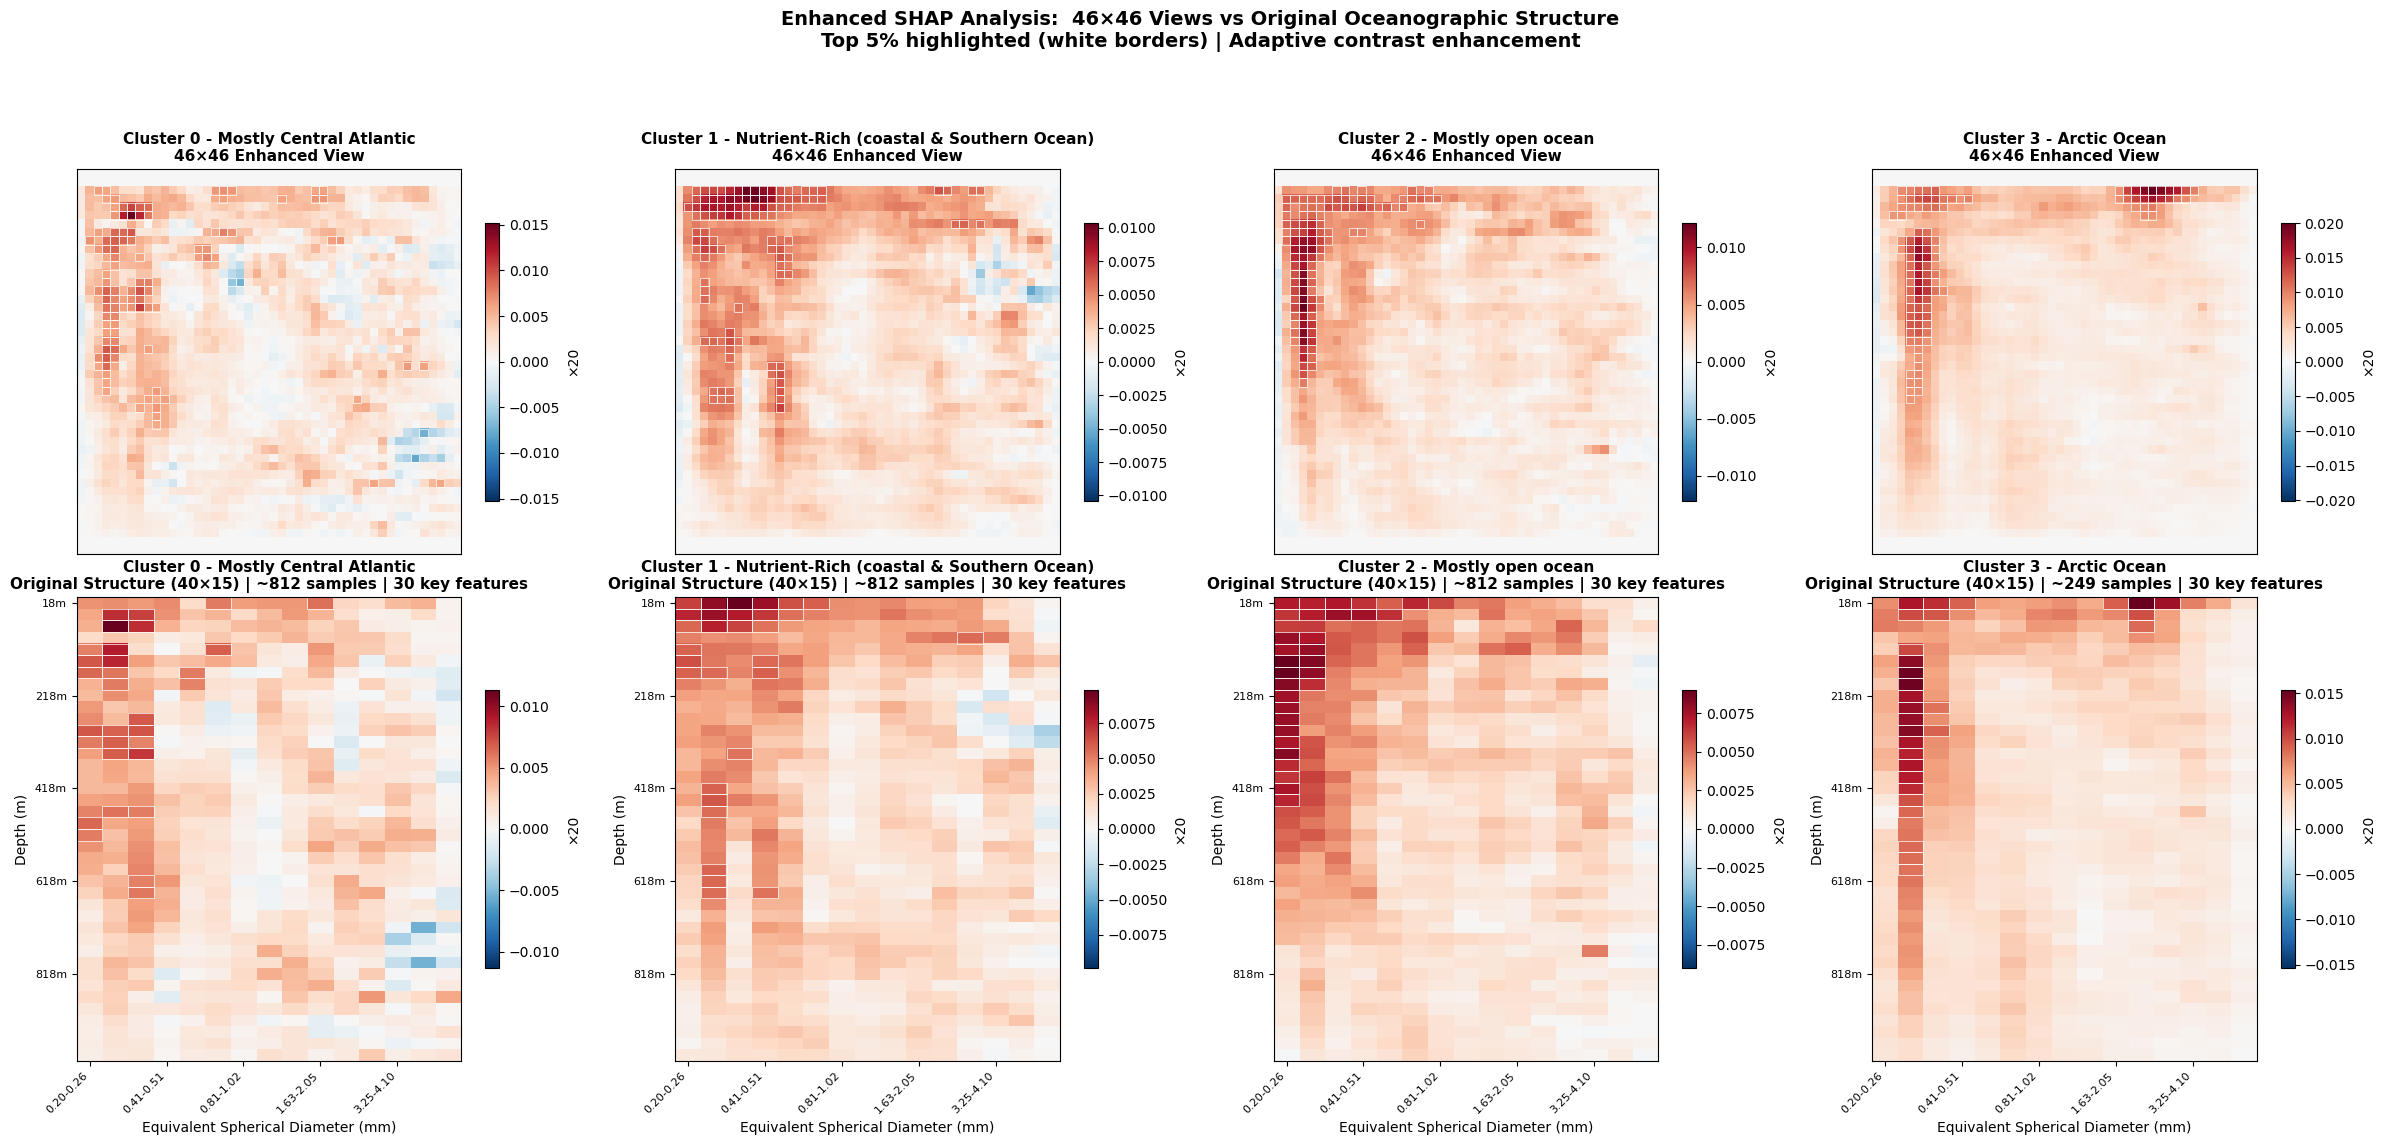

📊 Creating comparative analysis...


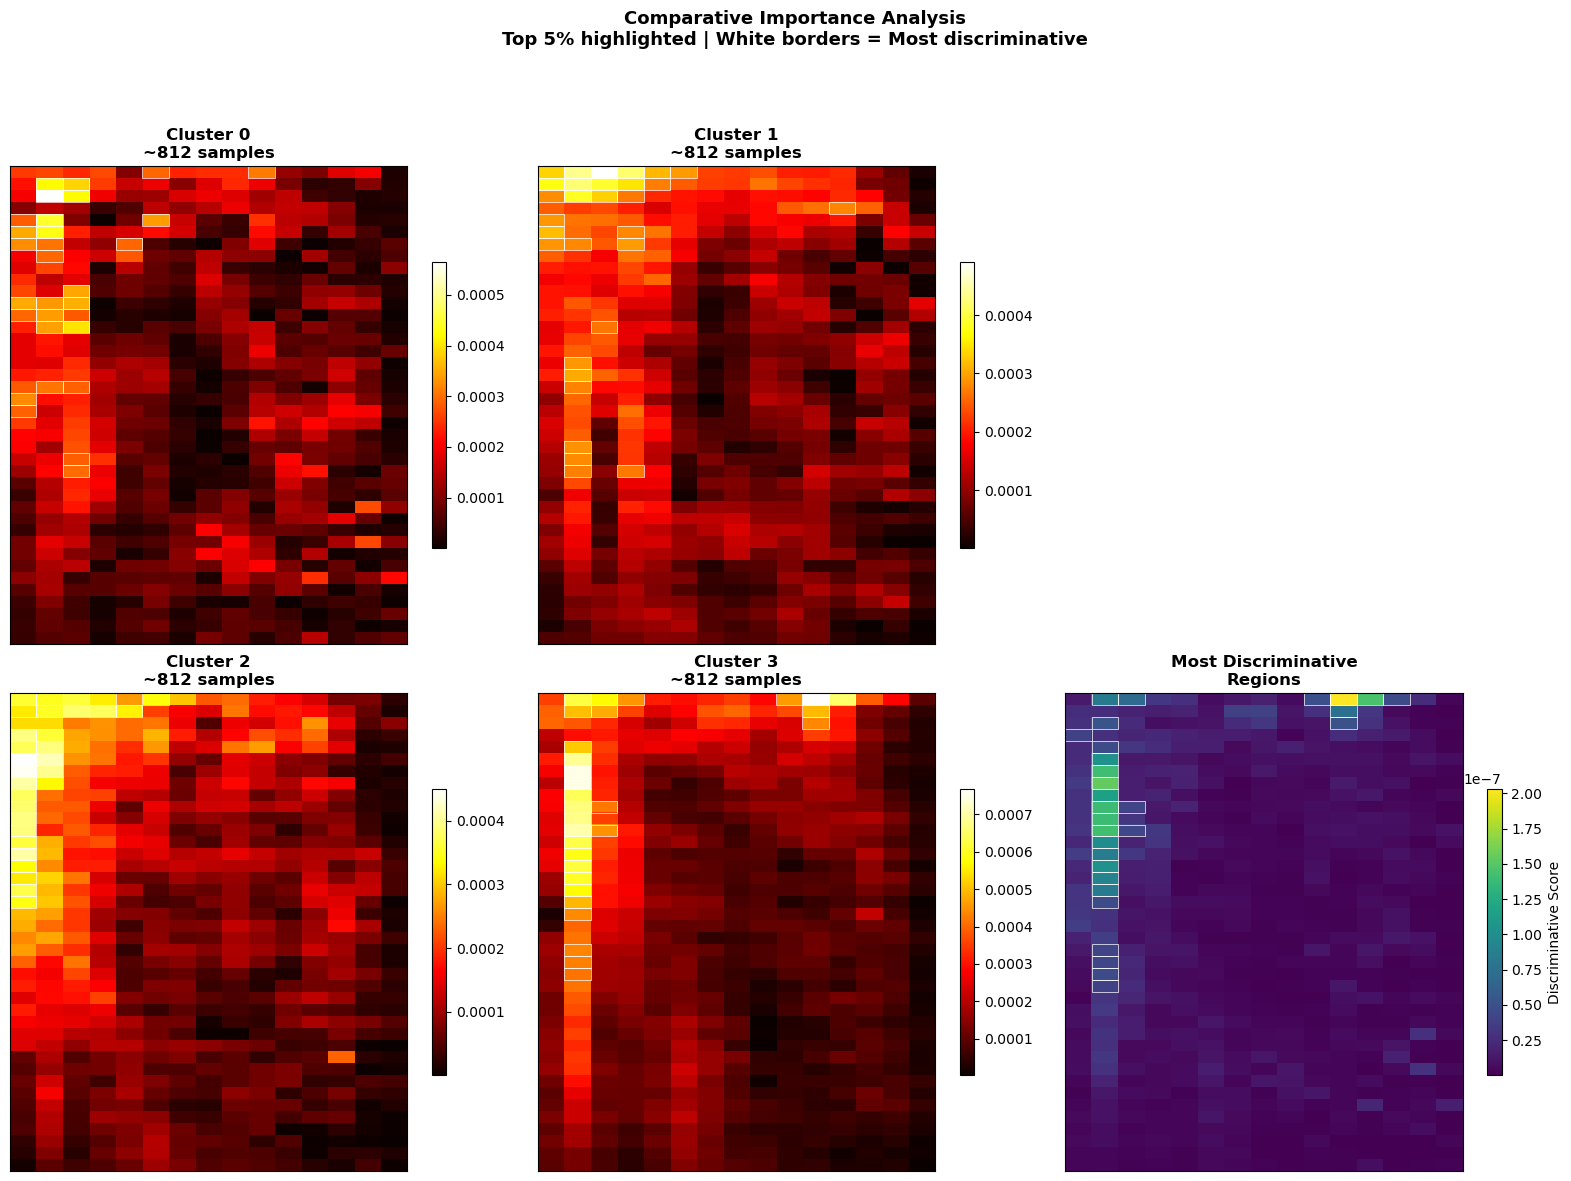


✅ Enhanced SHAP visualization completed!
🎨 Created:
  1. Enhanced 46×46 vs Original 40��15 comparison
  2. Comparative discriminative analysis


In [52]:
# Run complete enhanced visualization
cluster_shapes, discriminative = run_enhanced_shap_visualization_fixed()

# Next steps (from original notebook)

## Implementation

[Implement the final model(s) you've selected based on the above steps.]


In [ ]:
# Implement the final model(s)
# Example: model = YourChosenModel(best_hyperparameters)
# model.fit(X_train, y_train)


## Evaluation Metrics

[Clearly specify which metrics you'll use to evaluate the model performance, and why you've chosen these metrics.]


In [ ]:
# Evaluate the model using your chosen metrics
# Example for classification
# y_pred = model.predict(X_test)
# print(classification_report(y_test, y_pred))

# Example for regression
# mse = mean_squared_error(y_test, y_pred)

# Your evaluation code here


## Comparative Analysis

[Compare the performance of your model(s) against the baseline model. Discuss any improvements or setbacks and the reasons behind them.]


In [ ]:
# Comparative Analysis code (if applicable)
# Example: comparing accuracy of the baseline model and the new model
# print(f"Baseline Model Accuracy: {baseline_accuracy}, New Model Accuracy: {new_model_accuracy}")
